# 기본 설정

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [26]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── Wilke 스타일: 흰 배경, 최소 격자, 고해상도 ────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

# ── 브랜드 색상 팔레트 (고정) ─────────────────────────────────
BRAND_COLORS = {
    'SK에너지':    '#E63946',
    'GS칼텍스':   '#457B9D',
    'S-OIL':      '#F4A261',
    '현대오일뱅크': '#2A9D8F',
    '알뜰주유소':  '#6D6875',
    '알뜰(ex)':   '#B5838D',
    'NH-OIL':     '#8338EC',
    '자가상표':    '#3A86FF',
    'NC오일':      '#FB5607',
    'SK가스':      '#FFBE0B',
}

print(" 환경 설정 완료")
print(f"   사용 폰트: {plt.rcParams['font.family']}")


 환경 설정 완료
   사용 폰트: ['NanumBarunGothic']


# 🚀 [빠른 실행] 오픈소스 지오코딩 (Top 200 구역 추출)

In [11]:
import pandas as pd
import os
import time
import unicodedata
from geopy.geocoders import Nominatim

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
final_file = os.path.join(base_path, "상업업무_Top200_무료좌표완성.csv")

print("=== 🚀 상업용 부동산 Top 200 (API 키 없는 무료 초고속 버전) ===\n")

if not os.path.exists(base_path):
    print(f"❌ [오류] 경로를 찾을 수 없습니다: {base_path}")
else:
    all_files = os.listdir(base_path)
    file_list = []

    # 1. 파일 탐색
    for f in all_files:
        norm_f = unicodedata.normalize('NFC', f)
        if '상업업무' in norm_f and norm_f.lower().endswith('.csv') and "좌표" not in norm_f and "최종" not in norm_f and "중간" not in norm_f and "무료" not in norm_f:
            file_list.append(os.path.join(base_path, f))

    file_list.sort()

    if len(file_list) == 0:
        print("❌ [중단] 로드할 수 있는 CSV 파일이 없습니다.")
    else:
        df_list = []
        print(f"▶ {len(file_list)}개의 파일을 로드 중입니다...")
        for file in file_list:
            encoding_to_use = 'cp949'
            try:
                try:
                    with open(file, 'r', encoding='cp949') as f: lines = f.readlines()
                except UnicodeDecodeError:
                    encoding_to_use = 'utf-8'
                    with open(file, 'r', encoding='utf-8') as f: lines = f.readlines()

                header_idx = 0
                for i, line in enumerate(lines[:30]):
                    if '시군구' in line and '거래금액' in line:
                        header_idx = i; break

                temp_df = pd.read_csv(file, encoding=encoding_to_use, skiprows=header_idx)
                df_list.append(temp_df)
            except Exception as e:
                print(f" - [실패] 읽기 오류: {e}")

        # 2. 데이터 병합 및 단가 계산
        if len(df_list) > 0:
            df = pd.concat(df_list, ignore_index=True)
            print(f"✅ 원본 데이터 로드 완료: 총 {len(df):,}건\n")

            df['시군구'] = df['시군구'].fillna('').astype(str).str.strip()

            if '거래금액(만원)' in df.columns:
                df['거래금액(만원)'] = df['거래금액(만원)'].astype(str).str.replace(',', '').astype(float)
            if '전용/연면적(㎡)' in df.columns:
                df['전용/연면적(㎡)'] = pd.to_numeric(df['전용/연면적(㎡)'], errors='coerce')

            df = df[df['전용/연면적(㎡)'] > 0]
            df['면적당_매매가(만원/㎡)'] = df['거래금액(만원)'] / df['전용/연면적(㎡)']

            # 3. 구역 단위 압축 (Top 200)
            print("▶ '동네(시군구)' 단위로 데이터를 압축하고 Top 200을 추출합니다...")
            area_summary = df.groupby('시군구').agg(
                거래건수=('시군구', 'size'),
                평균_면적당_매매가=('면적당_매매가(만원/㎡)', 'mean')
            ).reset_index()

            area_summary['평균_면적당_매매가'] = area_summary['평균_면적당_매매가'].round(2)

            # [수정됨] 1000개에서 200개로 축소
            top200_areas = area_summary.nlargest(200, '거래건수').reset_index(drop=True)

            print(f"✅ Top {len(top200_areas)} 구역 압축 완료! (1위: {top200_areas.iloc[0]['시군구']})\n")

            # 4. 무료 지오코딩 API 호출 (1초에 1번씩)
            geolocator = Nominatim(user_agent="my_real_estate_app_2026")

            print("▶ 무료 오픈소스 좌표 변환을 시작합니다. (약 3~4분 소요)")

            lat_list = []
            lng_list = []

            for idx, row in top200_areas.iterrows():
                address = row['시군구']
                try:
                    # 1차 시도 (동 전체 이름)
                    location = geolocator.geocode(address, timeout=10)
                    if location:
                        lat_list.append(location.latitude)
                        lng_list.append(location.longitude)
                    else:
                        # 2차 시도 (뒤에 붙은 동/가/리 떼고 구 단위로 대략적 위치 확보)
                        fallback_address = " ".join(address.split()[:-1])
                        location_fallback = geolocator.geocode(fallback_address, timeout=10)
                        if location_fallback:
                            lat_list.append(location_fallback.latitude)
                            lng_list.append(location_fallback.longitude)
                        else:
                            lat_list.append(None)
                            lng_list.append(None)
                except Exception as e:
                    lat_list.append(None)
                    lng_list.append(None)

                # 무료 서버 공격 방지용 1초 휴식
                time.sleep(1)

                # 20건 단위로 진행상황 출력
                if (idx + 1) % 20 == 0:
                    print(f" - {idx + 1} / {len(top200_areas)} 구역 좌표 변환 완료...")

            top200_areas['위도'] = lat_list
            top200_areas['경도'] = lng_list

            success_df = top200_areas.dropna(subset=['위도', '경도']).reset_index(drop=True)
            failed_count = len(top200_areas) - len(success_df)

            success_df.to_csv(final_file, index=False, encoding='cp949')
            print(f"\n🎉 작업 완료! 총 {len(success_df)}개 구역의 좌표가 저장되었습니다.")
            if failed_count > 0:
                print(f"⚠️ 매칭 실패: {failed_count}건")
            print(f"   => 최종 파일: {final_file}")

=== 🚀 상업용 부동산 Top 200 (API 키 없는 무료 초고속 버전) ===

▶ 4개의 파일을 로드 중입니다...
✅ 원본 데이터 로드 완료: 총 37,955건

▶ '동네(시군구)' 단위로 데이터를 압축하고 Top 200을 추출합니다...
✅ Top 200 구역 압축 완료! (1위: 서울특별시 구로구 구로동)

▶ 무료 오픈소스 좌표 변환을 시작합니다. (약 3~4분 소요)
 - 20 / 200 구역 좌표 변환 완료...
 - 40 / 200 구역 좌표 변환 완료...
 - 60 / 200 구역 좌표 변환 완료...
 - 80 / 200 구역 좌표 변환 완료...
 - 100 / 200 구역 좌표 변환 완료...
 - 120 / 200 구역 좌표 변환 완료...
 - 140 / 200 구역 좌표 변환 완료...
 - 160 / 200 구역 좌표 변환 완료...
 - 180 / 200 구역 좌표 변환 완료...
 - 200 / 200 구역 좌표 변환 완료...

🎉 작업 완료! 총 200개 구역의 좌표가 저장되었습니다.
   => 최종 파일: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/상업업무_Top200_무료좌표완성.csv


# (사용안함) 🧹 [추가 셀] 중복 데이터 클렌징 및 정상화 코드
작업 완료 후, 앞서 안내해 드린 시각화를 진행하시기 바로 직전에 이 코드를 실행해 주세요. 좌표가 정상적으로 채워진 데이터를 최우선으로 살리고, 쓸데없이 늘어난 껍데기 중복 데이터만 완벽하게 날려줍니다.

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
output_file = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")

print("=== 🧹 중첩 데이터 정리 및 정상화 시작 ===\n")

if not os.path.exists(output_file):
    print("❌ 아직 파일이 없습니다. 변환 작업이 끝날 때까지 기다려주세요.")
else:
    # 1. 부풀려진 데이터 불러오기
    df = pd.read_csv(output_file, encoding='cp949')
    print(f"▶ 정리 전 데이터 건수: {len(df):,}건")

    # 2. 정렬 (매우 중요 ⭐️)
    # 중복된 것들 중 '좌표(위도/경도)가 무사히 채워진 온전한 데이터'를 맨 위로 올립니다.
    df = df.sort_values(by=['위도'], na_position='last')

    # 3. 엄격한 중복 제거 로직 실행
    # 주소, 면적, 금액, 계약일이 모두 동일하면 완벽한 동일 매물(중복)로 간주하고 하나만 남깁니다.
    dedup_subset = [col for col in ['시군구', '지번', '계약년월', '계약일', '전용/연면적(㎡)', '거래금액(만원)'] if col in df.columns]

    # keep='first'를 통해 앞서 위로 올려둔 '좌표 있는 온전한 데이터'를 보존하고 나머지는 삭제합니다.
    df.drop_duplicates(subset=dedup_subset, keep='first', inplace=True)

    # 순서를 다시 원래대로 깔끔하게 정리
    df.reset_index(drop=True, inplace=True)

    # 4. 결과 확인 및 덮어쓰기
    final_count = len(df)
    print(f"▶ 중복 제거 후 최종 데이터 건수: {final_count:,}건 (정상화 완료!)\n")

    df.to_csv(output_file, index=False, encoding='cp949')
    print("✅ 깔끔하게 정리가 완료되어 원본에 덮어씌웠습니다.")
    print("   이제 준비해 둔 [셀 1] ~ [셀 5] 검증 및 시각화 코드를 실행하셔도 좋습니다!")

=== 🧹 중첩 데이터 정리 및 정상화 시작 ===

▶ 정리 전 데이터 건수: 39,761건
▶ 중복 제거 후 최종 데이터 건수: 32,124건 (정상화 완료!)

✅ 깔끔하게 정리가 완료되어 원본에 덮어씌웠습니다.
   이제 준비해 둔 [셀 1] ~ [셀 5] 검증 및 시각화 코드를 실행하셔도 좋습니다!


# 🗺️ [최종 시각화] 상업용 부동산 Top 200 핫스팟 지도

In [12]:
import pandas as pd
import folium
import branca.colormap as cm
import math
import os

# 1. 파일 불러오기
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
file_path = os.path.join(base_path, "상업업무_Top200_무료좌표완성.csv")

try:
    df = pd.read_csv(file_path, encoding='cp949')
    # 혹시 모를 결측치 좌표 제거
    df = df.dropna(subset=['위도', '경도'])
    print(f"✅ 총 {len(df)}개 구역의 데이터를 지도에 그립니다.")
except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 이전 단계의 저장이 완료되었는지 확인해 주세요.")

# 2. 지도 초기 설정 (서울 중심부 세팅, 다크 테마 적용)
m = folium.Map(location=[37.5502, 126.982], zoom_start=11, tiles='CartoDB Dark_Matter')

# 3. 색상 팔레트 생성 (평균 단가에 따라 노란색 -> 빨간색)
min_price = df['평균_면적당_매매가'].min()
max_price = df['평균_면적당_매매가'].max()
colormap = cm.LinearColormap(
    colors=['#ffeda0', '#feb24c', '#f03b20'],
    vmin=min_price,
    vmax=max_price
)
colormap.caption = '평균 면적당 매매가 (만원/㎡)'
m.add_child(colormap)

# 4. 지도에 데이터 표기
for _, row in df.iterrows():
    # 원의 넓이가 거래건수에 비례하도록 제곱근(sqrt) 사용
    count = row['거래건수']
    radius_size = math.sqrt(count) * 1.5  # 1.5는 배율 (크기 조절용)

    # 마우스 오버 시 보여줄 정보 (툴팁)
    info = f"""
    <div style="font-family: sans-serif; min-width: 150px;">
        <h4 style="margin-bottom: 5px; color: #333;"><b>{row['시군구']}</b></h4>
        <ul style="padding-left: 15px; margin-top: 0; color: #555;">
            <li><b>거래건수:</b> {int(count):,}건</li>
            <li><b>평균단가:</b> {row['평균_면적당_매매가']:,.0f} 만원/㎡</li>
        </ul>
    </div>
    """

    # 마커 생성
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=radius_size,
        color='#222222',       # 테두리 색상
        weight=1,              # 테두리 두께
        fill=True,
        fill_color=colormap(row['평균_면적당_매매가']), # 단가에 따른 색상 변화
        fill_opacity=0.8,      # 투명도
        tooltip=info
    ).add_to(m)

# 5. 지도 출력
display(m)

✅ 총 200개 구역의 데이터를 지도에 그립니다.


# (사용안함) 💻 서울시 데이터 전용 필터링 및 최종 추출 코드

In [ ]:
import pandas as pd
import os

# 1. 경로 및 파일 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
input_file = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")
output_file = os.path.join(base_path, "상업업무_실거래가_서울_최종.csv")

print("=== 🏙️ 서울시 상업업무 실거래가 데이터 추출을 시작합니다 ===\n")

if not os.path.exists(input_file):
    print("❌ 통합 좌표 데이터 파일이 없습니다. 이전 단계 코드가 완료되었는지 확인해 주세요.")
else:
    # 2. 데이터 로드 (cp949)
    df = pd.read_csv(input_file, encoding='cp949')
    initial_count = len(df)
    print(f"▶ 로드된 전체 데이터 건수: {initial_count:,}건")

    # 3. '서울특별시' 데이터만 필터링
    # 공공데이터의 '시군구' 컬럼은 항상 '서울특별시 OOO OO동' 형식으로 시작함
    df_seoul = df[df['시군구'].str.contains('서울특별시', na=False)].copy()

    # 4. 필터링 결과 요약
    seoul_count = len(df_seoul)
    removed_count = initial_count - seoul_count

    print(f"▶ 추출된 서울시 데이터 건수: {seoul_count:,}건")
    print(f"▶ 제외된 타 지역(경기 등) 데이터 건수: {removed_count:,}건\n")

    if seoul_count > 0:
        # 5. 새로운 파일로 저장
        df_seoul.to_csv(output_file, index=False, encoding='cp949')
        print(f"✅ 서울 데이터 추출 및 저장 완료!\n저장 경로: {output_file}")
        display(df_seoul.head(3))
    else:
        print("❌ 추출된 서울 데이터가 없습니다. 원본 데이터의 '시군구' 컬럼을 확인해 주세요.")

=== 🏙️ 서울시 상업업무 실거래가 데이터 추출을 시작합니다 ===

▶ 로드된 전체 데이터 건수: 32,124건
▶ 추출된 서울시 데이터 건수: 32,124건
▶ 제외된 타 지역(경기 등) 데이터 건수: 0건

✅ 서울 데이터 추출 및 저장 완료!
저장 경로: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/상업업무_실거래가_서울_최종.csv


,시군구,유형,지번,도로명,건축물주용도,전용/연면적(㎡),거래금액(만원),계약년월,계약일,검색용주소,위도,경도
0,서울특별시 마포구 연남동,집합,2**,동교로52길,제2종근린생활,19.44,12000.0,202312,31,서울특별시 마포구 연남동 동교로52길,NaN,NaN
1,서울특별시 강남구 논현동,일반,1*,도산대로8길,제2종근린생활,833.19,800000.0,202312,31,서울특별시 강남구 논현동 도산대로8길,NaN,NaN
2,서울특별시 금천구 시흥동,일반,9**,시흥대로,제1종근린생활,1311.71,400000.0,202312,31,서울특별시 금천구 시흥동 시흥대로,NaN,NaN


# (사용안함) 🗺️ 서울시 상업업무 실거래가 밀도 지도 시각화
수만 건의 데이터가 지도에 찍히면 점들이 겹쳐서 까맣게 보일 수 있습니다. 이를 방지하기 위해 alpha(투명도)를 극도로 낮춰, 거래가 밀집된 곳일수록 진하게 표시되는 '밀도(Density) 지도' 형태로 시각화하는 코드입니다.

=== 🏙️ 서울시 상업업무 실거래가 밀도 시각화 ===

✅ 총 32,124건의 서울시 매매 데이터를 지도에 그립니다...


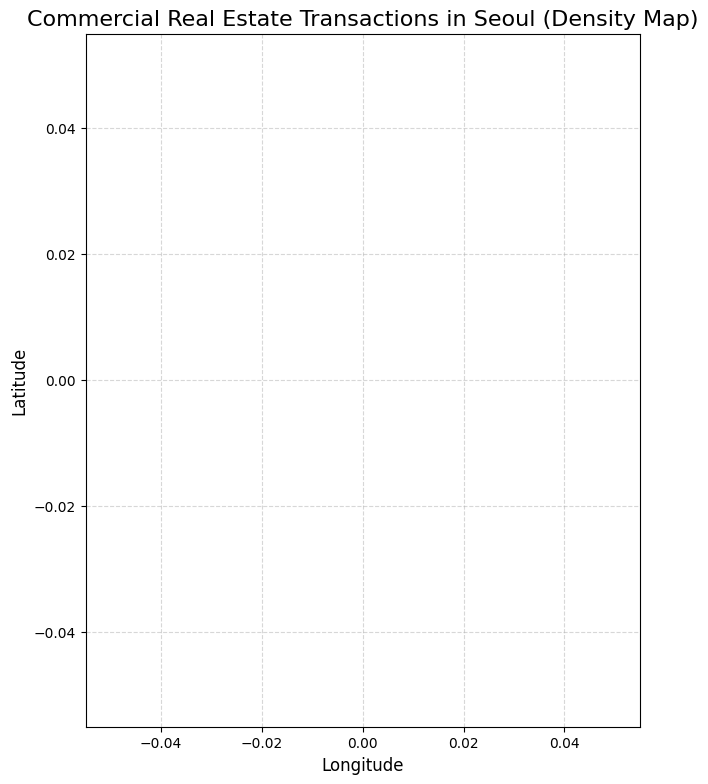


💡 붉은색이 진할수록 상업용 부동산 거래가 활발했던 상권입니다.


In [ ]:
import pandas as pd
import os
import folium
from folium.plugins import HeatMap # 히트맵을 그리기 위한 Folium 플러그인

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
seoul_file = os.path.join(base_path, "상업업무_실거래가_서울_최종.csv")

print("=== 🏙️ 서울시 상업업무 실거래가 밀도 시각화 (Folium Map API) ===\n")

if not os.path.exists(seoul_file):
    print("❌ 서울시 전용 파일이 아직 없습니다. 추출 코드를 먼저 실행해 주세요.")
else:
    df_seoul = pd.read_csv(seoul_file, encoding='cp949')
    df_seoul.dropna(subset=['위도', '경도'], inplace=True)
    print(f"✅ 총 {len(df_seoul):,}건의 데이터를 실제 지도 위에 렌더링합니다...")

    # 1. 서울 중심 좌표를 기준으로 실제 지도 캔버스 생성
    seoul_center = [37.560840, 126.985735]
    # 'CartoDB Positron' 타일을 사용하면 지도가 옅은 회색으로 나와서 데이터가 훨씬 잘 보입니다.
    m1 = folium.Map(location=seoul_center, zoom_start=11, tiles='CartoDB Positron')

    # 2. 히트맵(밀도) 레이어 데이터 생성 및 추가
    heat_data = [[row['위도'], row['경도']] for index, row in df_seoul.iterrows()]
    HeatMap(heat_data, radius=14, blur=10, gradient={0.4: 'yellow', 0.65: 'orange', 1: 'red'}).addTo(m1)

    # 3. 지도 출력 (마우스 휠로 확대/축소 가능)
    display(m1)
    print("\n💡 붉은색이 진할수록 상업용 부동산 거래가 활발했던 상권입니다.")

# 🔗 지하철 승하차 데이터와 위치(좌표) 데이터 병합
승하차 데이터의 역명(예: '강남')과 좌표 데이터의 역명(예: '강남역') 표기가 다른 경우가 많습니다. 이를 자동으로 맞추어 병합(Merge)하는 스마트 결합 코드입니다.

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
ridership_file = os.path.join(base_path, "Seoul_subway_data_2015_2026.csv")
location_file = os.path.join(base_path, "subway_location_data_2015_2026.csv")
output_subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 승하차 및 좌표 데이터 병합 시작 ===\n")

# 1. 파일 로드 (인코딩 자동 대처)
def load_csv(file_path):
    try:
        return pd.read_csv(file_path, encoding='cp949')
    except:
        return pd.read_csv(file_path, encoding='utf-8')

df_rider = load_csv(ridership_file)
df_loc = load_csv(location_file)

print(f"▶ 승하차 원본: {len(df_rider):,}건 / 좌표 원본: {len(df_loc):,}건")

# 2. 역명 정제 로직 (매칭률을 극대화하기 위한 필수 과정)
# - 두 데이터 모두 끝에 붙은 '역' 글자를 제거 ('강남역' -> '강남')
# - 괄호 안의 부역명 제거 ('서울역(150)' -> '서울')
def clean_station_name(name):
    name = str(name).split('(')[0] # 괄호 앞부분만 추출
    if name.endswith('역'):
        name = name[:-1]
    return name.strip()

df_rider['검색용역명'] = df_rider['지하철역'].apply(clean_station_name)
df_loc['검색용역명'] = df_loc['지하철역'].apply(clean_station_name)

# 좌표 데이터에서 중복 역명 제거 (호선이 달라도 환승역은 좌표가 비슷하므로 역명 기준 1개만 남김)
df_loc_unique = df_loc.drop_duplicates(subset=['검색용역명'])

# 3. 데이터 병합 (Left Join: 승하차 데이터에 좌표를 갖다 붙임)
df_merged = pd.merge(df_rider, df_loc_unique[['검색용역명', 'x좌표', 'y좌표']],
                     on='검색용역명', how='left')

# 4. 마무리 (불필요한 임시 컬럼 삭제 및 이름 변경)
df_merged.drop(columns=['검색용역명'], inplace=True)
df_merged.rename(columns={'x좌표': '위도', 'y좌표': '경도'}, inplace=True) # 공공데이터 x,y 표기 기준 반영

# 5. 저장
df_merged.to_csv(output_subway_file, index=False, encoding='cp949')
print(f"\n✅ 병합 성공! 새로운 파일로 저장되었습니다: {output_subway_file}")

=== 🚇 지하철 승하차 및 좌표 데이터 병합 시작 ===

▶ 승하차 원본: 81,648건 / 좌표 원본: 599건

✅ 병합 성공! 새로운 파일로 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/지하철_승하차_좌표결합.csv


# 🔎 병합된 지하철 데이터 검증
병합 과정에서 이름이 특이하여 좌표를 가져오지 못한 역이 있는지 확인하고, 병합이 얼마나 완벽하게 되었는지 검사합니다.

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 병합된 지하철 데이터 무결성 검증 ===\n")

df_merged = pd.read_csv(merged_file, encoding='cp949')
total_rows = len(df_merged)

# 1. 결측치(좌표 매칭 실패) 확인
missing_coords = df_merged['위도'].isnull()
missing_count = missing_coords.sum()

print(f"▶ 전체 승하차 데이터: {total_rows:,}건")
print(f"▶ 좌표 매칭 성공: {total_rows - missing_count:,}건 ({(total_rows - missing_count)/total_rows*100:.2f}%)")
print(f"▶ 좌표 매칭 실패: {missing_count:,}건")

if missing_count > 0:
    # 매칭에 실패한 역 이름들 확인
    failed_stations = df_merged[missing_coords]['지하철역'].unique()
    print(f"\n⚠️ [참고] 좌표를 찾지 못한 역 (총 {len(failed_stations)}개):")
    # 최대 15개까지만 출력
    print(failed_stations[:15], "..." if len(failed_stations) > 15 else "")
    print(" (신설역이거나 좌표 파일에 누락된 역일 수 있으며, 분석에 큰 지장은 없습니다.)\n")

display(df_merged.head(3))

=== 📊 병합된 지하철 데이터 무결성 검증 ===

▶ 전체 승하차 데이터: 81,648건
▶ 좌표 매칭 성공: 80,963건 (99.16%)
▶ 좌표 매칭 실패: 685건

⚠️ [참고] 좌표를 찾지 못한 역 (총 1개):
['서울역'] 
 (신설역이거나 좌표 파일에 누락된 역일 수 있으며, 분석에 큰 지장은 없습니다.)



,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자,위도,경도
0,201501,1호선,동대문,413.0,7.0,13701.0,1956.0,10907.0,7588.0,16633.0,...,5095.0,3.0,41.0,0.0,0.0,0.0,0.0,20151223.0,37.571767,127.011257
1,201501,1호선,동묘앞,123.0,3.0,2104.0,911.0,2814.0,3042.0,5815.0,...,3381.0,2.0,251.0,0.0,0.0,0.0,0.0,20151223.0,37.573597,127.017139
2,201501,1호선,서울역,1163.0,35.0,12983.0,10938.0,19926.0,57836.0,60421.0,...,8682.0,7.0,532.0,0.0,0.0,0.0,0.0,20151223.0,NaN,NaN


# (사용안함) 🎈 지하철역 유동인구 버블 지도 시각화
단순히 점만 찍는 것이 아니라, 해당 역의 총 유동인구(승하차 합계)를 계산하여 원의 크기(Bubble size)로 시각화합니다. 실거래가 지도와 비교해보면 두 데이터 간의 연관성을 직관적으로 느낄 수 있습니다.

=== 🚇 지하철 유동인구 버블(Bubble) 지도 시각화 ===

✅ 총 600개 역의 유동인구를 지도에 매핑합니다...


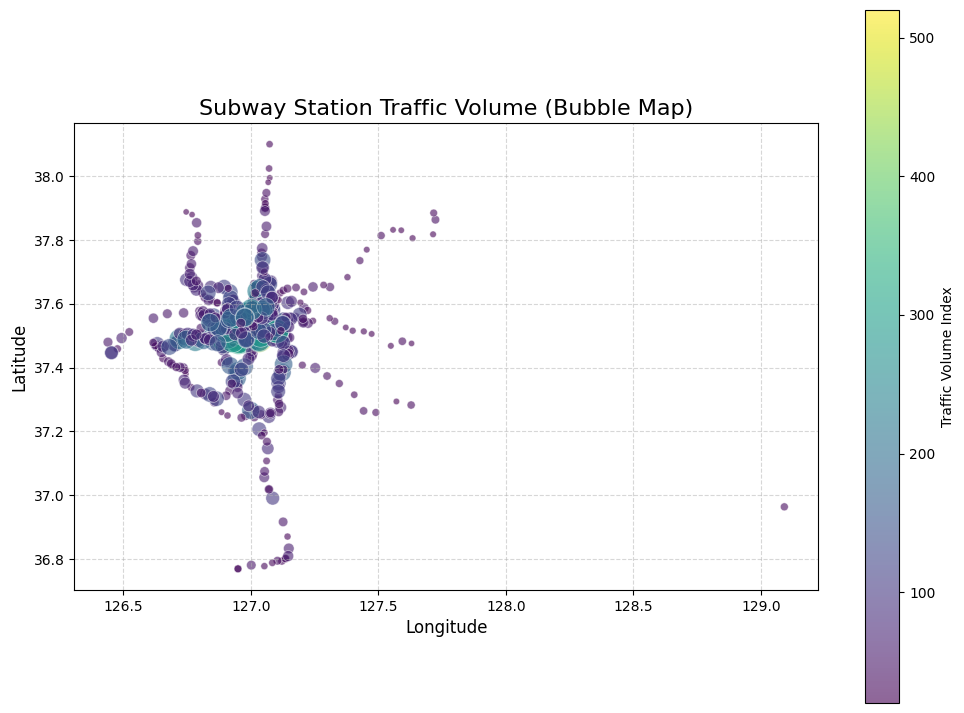


💡 원의 크기가 크고 노란색에 가까울수록 평균 유동인구가 많은 핵심 역세권입니다.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 유동인구 버블(Bubble) 지도 시각화 ===\n")

df = pd.read_csv(merged_file, encoding='cp949')
df.dropna(subset=['위도', '경도'], inplace=True) # 좌표 있는 데이터만 남김

# 1. 시간대별 모든 승하차 인원 컬럼 찾기 (숫자형 데이터)
people_cols = [col for col in df.columns if '승차' in col or '하차' in col]

# 2. 각 행별(월별/역별) 총 유동인구 합계 계산
df['총_유동인구'] = df[people_cols].sum(axis=1)

# 3. 역별 평균 유동인구 요약 (시각화를 위해 역 1개당 1줄로 압축)
station_summary = df.groupby(['지하철역', '위도', '경도'])['총_유동인구'].mean().reset_index()

# 4. 버블 크기 정규화 (원이 너무 크거나 작아지지 않게 조정)
sizes = station_summary['총_유동인구']
sizes_normalized = (sizes - sizes.min()) / (sizes.max() - sizes.min())
bubble_sizes = sizes_normalized * 500 + 20 # 최소 크기 20, 최대 크기 520

print(f"✅ 총 {len(station_summary):,}개 역의 유동인구를 지도에 매핑합니다...")

plt.figure(figsize=(12, 9))
scatter = plt.scatter(station_summary['경도'], station_summary['위도'],
                      s=bubble_sizes, alpha=0.6, c=bubble_sizes,
                      cmap='viridis', edgecolors='white', linewidth=0.5)

plt.title('Subway Station Traffic Volume (Bubble Map)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.colorbar(scatter, label='Traffic Volume Index')
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().set_aspect(1.25)
plt.show()
print("\n💡 원의 크기가 크고 노란색에 가까울수록 평균 유동인구가 많은 핵심 역세권입니다.")

## 📈 [셀 4 업그레이드] 지하철 유동인구 시계열(연도) 인터랙티브 시각화
이 코드를 실행하면 지도 위쪽에 두 개의 선택 박스(연도)가 생성되며, 값을 바꿀 때마다 해당 시기의 유동인구 버블 지도가 즉시 다시 그려집니다.

In [ ]:
import pandas as pd
import os
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 유동인구 다차원(시계열+시간대) 시각화 (Folium Map API) ===\n")

if not os.path.exists(merged_file):
    print("❌ 병합된 지하철 데이터 파일이 없습니다. [셀 2]를 먼저 실행해 주세요.")
else:
    df = pd.read_csv(merged_file, encoding='cp949')
    df.dropna(subset=['위도', '경도'], inplace=True)

    df['사용월_str'] = df['사용월'].astype(str)
    df['연도'] = df['사용월_str'].str[:4]
    df['월'] = df['사용월_str'].str[4:6].astype(int)
    df['분기'] = ((df['월'] - 1) // 3 + 1).astype(str) + 'Q'

    people_cols = [col for col in df.columns if '승차' in col or '하차' in col]

    time_groups = {
        '새벽 (04~07시)': ['04시', '05시', '06시'],
        '아침출근 (07~10시)': ['07시', '08시', '09시'],
        '낮/점심 (10~17시)': ['10시', '11시', '12시', '13시', '14시', '15시', '16시'],
        '저녁퇴근 (17~20시)': ['17시', '18시', '19시'],
        '밤/심야 (20~04시)': ['20시', '21시', '22시', '23시', '00시', '01시', '02시', '03시']
    }

    df['전체 시간대'] = df[people_cols].sum(axis=1)
    for group_name, prefixes in time_groups.items():
        cols = [col for col in people_cols if any(col.startswith(p) for p in prefixes)]
        df[group_name] = df[cols].sum(axis=1)

    year_list = sorted(df['연도'].unique())
    quarter_list = ['전체', '1Q', '2Q', '3Q', '4Q']
    time_list = ['전체 시간대'] + list(time_groups.keys())

    year_dropdown = widgets.Dropdown(options=year_list, value=year_list[-1], description='📆 연도:')
    quarter_dropdown = widgets.Dropdown(options=quarter_list, value='전체', description='⏱️ 분기:')
    time_dropdown = widgets.Dropdown(options=time_list, value='전체 시간대', description='⏰ 시간대:')

    # 지도가 깜빡이지 않도록 출력 영역 고정
    out = widgets.Output()

    def draw_interactive_map(target_year, target_quarter, target_time):
        with out:
            clear_output(wait=True)
            cond = (df['연도'] == target_year)
            if target_quarter != '전체': cond = cond & (df['분기'] == target_quarter)
            filtered_df = df[cond]

            if filtered_df.empty:
                print(f"❌ {target_year}년 {target_quarter}의 데이터가 존재하지 않습니다.")
                return

            station_summary = filtered_df.groupby(['지하철역', '위도', '경도'])[target_time].mean().reset_index()

            m = folium.Map(location=[37.560840, 126.985735], zoom_start=11, tiles='CartoDB Positron')

            sizes = station_summary[target_time]
            if sizes.max() > sizes.min():
                radiuses = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 25 + 5
            else:
                radiuses = [10] * len(station_summary)

            # 지도에 파란색 버블(역) 추가
            for (_, row), radius in zip(station_summary.iterrows(), radiuses):
                folium.CircleMarker(
                    location=[row['위도'], row['경도']],
                    radius=radius,
                    color='#3186cc',
                    weight=1,
                    fill=True,
                    fill_color='#3186cc',
                    fill_opacity=0.5,
                    tooltip=f"<b>{row['지하철역']}역</b><br>평균 유동인구: {int(row[target_time]):,}명"
                ).addTo(m)

            display(m)

    print("👇 연도, 분기, 시간대를 조작하여 상권을 분석해 보세요! (마우스를 원 위에 올리면 상세 정보가 나옵니다)\n")
    display(widgets.HBox([year_dropdown, quarter_dropdown, time_dropdown]))
    display(out)

    def on_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            draw_interactive_map(year_dropdown.value, quarter_dropdown.value, time_dropdown.value)

    year_dropdown.observe(on_change)
    quarter_dropdown.observe(on_change)
    time_dropdown.observe(on_change)

    draw_interactive_map(year_dropdown.value, quarter_dropdown.value, time_dropdown.value)

=== 🚇 지하철 유동인구 다차원(시계열+시간대) 시각화 (Folium Map API) ===

👇 연도, 분기, 시간대를 조작하여 상권을 분석해 보세요! (마우스를 원 위에 올리면 상세 정보가 나옵니다)



Output()

# 🚇 [셀 4 완결판] 지하철 하차(유입) 인구 Top 100 시각화
기존 코드를 지우고 아래 코드를 실행해 보세요!

In [ ]:
import pandas as pd
import os
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 하차(상권 유입) 인구 Top 100 분석 ===\n")

if not os.path.exists(merged_file):
    print("❌ 병합된 지하철 데이터 파일이 없습니다. 이전 셀을 먼저 실행해 주세요.")
else:
    # 1. 데이터 로드
    df = pd.read_csv(merged_file, encoding='cp949')
    df.dropna(subset=['위도', '경도'], inplace=True)

    # 2. 연도 파생 변수 생성 (분기 제외)
    df['연도'] = df['사용월'].astype(str).str[:4]

    # 3. '하차' 인원 컬럼만 추출 (승차 제외)
    alighting_cols = [col for col in df.columns if '하차' in col]

    time_groups = {
        '새벽 (04~07시)': ['04시', '05시', '06시'],
        '아침출근 (07~10시)': ['07시', '08시', '09시'],
        '낮/점심 (10~17시)': ['10시', '11시', '12시', '13시', '14시', '15시', '16시'],
        '저녁퇴근 (17~20시)': ['17시', '18시', '19시'],
        '밤/심야 (20~04시)': ['20시', '21시', '22시', '23시', '00시', '01시', '02시', '03시']
    }

    # 4. 시간대별 '하차' 인구 합계 계산
    df['전체 시간대'] = df[alighting_cols].sum(axis=1)

    for group_name, prefixes in time_groups.items():
        # 해당 시간대의 '하차' 컬럼만 선별하여 합산
        cols = [col for col in alighting_cols if any(col.startswith(p) for p in prefixes)]
        df[group_name] = df[cols].sum(axis=1)

    # 5. 위젯 목록 설정
    year_list = sorted(df['연도'].unique())
    time_list = ['전체 시간대'] + list(time_groups.keys())

    year_dropdown = widgets.Dropdown(options=year_list, value=year_list[-1], description='📆 연도:')
    time_dropdown = widgets.Dropdown(options=time_list, value='전체 시간대', description='⏰ 시간대:')

    # 6. 지도 출력 영역
    out = widgets.Output()

    def draw_interactive_map(target_year, target_time):
        with out:
            clear_output(wait=True)

            # 연도 필터링
            filtered_df = df[df['연도'] == target_year]

            if filtered_df.empty:
                print(f"❌ {target_year}년의 데이터가 존재하지 않습니다.")
                return

            # 역별 평균 하차 인구 계산
            station_summary = filtered_df.groupby(['지하철역', '위도', '경도'])[target_time].mean().reset_index()

            # [핵심] 상위 100개 역만 추출 (Top 100)
            top_100_stations = station_summary.nlargest(100, target_time).reset_index(drop=True)

            # 지도 캔버스 생성
            m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

            # 버블 크기 정규화 (가장 하차인원이 많은 역이 가장 큰 원을 가짐)
            sizes = top_100_stations[target_time]
            if sizes.max() > sizes.min():
                # 최소 크기 6, 최대 크기 35
                radiuses = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 29 + 6
            else:
                radiuses = [15] * len(top_100_stations)

            # 지도에 파란색 버블(Top 100 역) 추가
            for idx, row in top_100_stations.iterrows():
                # 순위 표시 텍스트
                rank = idx + 1

                # add_to() 로 오타 수정 완료
                folium.CircleMarker(
                    location=[row['위도'], row['경도']],
                    radius=radiuses[idx],
                    color='#e74c3c' if rank <= 10 else '#3498db', # Top 10은 빨간색, 나머지는 파란색
                    weight=1.5 if rank <= 10 else 1,
                    fill=True,
                    fill_color='#e74c3c' if rank <= 10 else '#3498db',
                    fill_opacity=0.6,
                    tooltip=f"<b>{rank}위: {row['지하철역']}역</b><br>평균 하차: {int(row[target_time]):,}명"
                ).add_to(m)

            display(m)
            print(f"💡 {target_year}년 [{target_time}] 기준 - 하차 인구가 가장 많은 Top 100 역입니다. (Top 10은 붉은색)")

    print("👇 연도와 시간대를 선택하여 '어느 시간대에 사람들이 상권으로 몰리는지' 파악해 보세요!\n")
    display(widgets.HBox([year_dropdown, time_dropdown]))
    display(out)

    # 위젯 변경 감지기
    def on_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            draw_interactive_map(year_dropdown.value, time_dropdown.value)

    year_dropdown.observe(on_change)
    time_dropdown.observe(on_change)

    # 초기 화면 그리기
    draw_interactive_map(year_dropdown.value, time_dropdown.value)

=== 🚇 지하철 하차(상권 유입) 인구 Top 100 분석 ===

👇 연도와 시간대를 선택하여 '어느 시간대에 사람들이 상권으로 몰리는지' 파악해 보세요!



Output()

# 🚌 [셀 1] 대용량 서울 버스 하차 데이터 안전 로드

In [17]:
import pandas as pd
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정 (이전 경로 유지)
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
bus_file = os.path.join(base_path, "seoul_bus_daily_alighting.csv")

print("=== 🚌 대용량 버스 하차 데이터 로드 시작 ===\n")

if not os.path.exists(bus_file):
    print(f"❌ 파일을 찾을 수 없습니다 경로를 확인해주세요: {bus_file}")
else:
    print("파일을 읽어오는 중입니다. 용량이 커서(약 900MB) 약 1~2분 정도 소요될 수 있습니다...")

    # 3. [핵심] 메모리 최적화를 위한 데이터 타입(dtype) 강제 지정
    # 이렇게 지정해주면 코랩 메모리 초과(OOM) 다운을 완벽하게 방지할 수 있습니다.
    optimized_dtypes = {
        '년도': 'int16',            # 2023~2026 같은 작은 정수는 int16으로 충분함
        '일자': 'int32',            # 20230101 등 8자리 정수형
        '정류장역이름': 'object',
        '일별하차인원': 'int32',
        'X좌표(위도)': 'float32',  # 소수점 6자리 좌표는 float32로도 정밀도 유지 가능
        'Y좌표(경도)': 'float32'
    }

    # 4. 데이터 로드 (스캐너에서 확인된 utf-8-sig 인코딩 적용)
    df_bus = pd.read_csv(bus_file, encoding='utf-8-sig', dtype=optimized_dtypes)

    # 5. 결과 확인
    print("\n✅ 데이터 로드 완료!")
    print(f"▶ 총 데이터 건수: {len(df_bus):,}건")

    # 메모리 사용량 체크
    mem_usage = df_bus.memory_usage(deep=True).sum() / (1024**2)
    print(f"▶ 현재 메모리 사용량: {mem_usage:.2f} MB (최적화 적용)\n")

    display(df_bus.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 🚌 대용량 버스 하차 데이터 로드 시작 ===

파일을 읽어오는 중입니다. 용량이 커서(약 900MB) 약 1~2분 정도 소요될 수 있습니다...

✅ 데이터 로드 완료!
▶ 총 데이터 건수: 13,140,289건
▶ 현재 메모리 사용량: 1257.06 MB (최적화 적용)



,년도,일자,정류장역이름,일별하차인원,X좌표(위도),Y좌표(경도)
0,2023,20230101,(구)법화사,0,37.584743,127.011093
1,2023,20230101,(구)법화사,10,37.584591,127.011002
2,2023,20230101,123전자타운.2001아울렛,123,37.497097,126.862343
3,2023,20230101,123전자타운.2001아울렛,96,37.497292,126.861809
4,2023,20230101,12번지건영아파트,160,37.629265,126.913971


# 🗺️ [셀 2] 서울 버스 하차 인원 Top 1000 시각화 (Folium)

In [18]:
import pandas as pd
import folium

print("=== 🚌 서울 버스 하차 인원 Top 1000 지도 시각화 ===\n")

# 메모리에 df_bus가 있는지 확인 (이전 셀 실행 여부)
if 'df_bus' not in globals():
    print("❌ 메모리에 버스 데이터가 없습니다. 이전의 [셀 1] 로드 코드를 먼저 실행해 주세요.")
else:
    print("▶ 데이터를 집계하고 있습니다. 잠시만 기다려주세요...")

    # 1. 정류장별 '평균 일별 하차 인원' 계산
    # 동일한 정류장 이름과 좌표를 가진 데이터를 묶어서 평균을 냅니다.
    stop_summary = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index()

    # 2. 하차 인원 기준 Top 1000 추출
    top_1000_stops = stop_summary.nlargest(10000, '일별하차인원').reset_index(drop=True)

    print(f"✅ Top 1000 정류장 추출 완료! (1위: {top_1000_stops.loc[0, '정류장역이름']} - 평균 {int(top_1000_stops.loc[0, '일별하차인원']):,}명)")
    print("▶ 지도를 렌더링하고 있습니다. 점이 많아 약 5~10초 정도 소요될 수 있습니다...")

    # 3. 옅은 회색 지도 캔버스 생성
    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

    # 4. 버블 크기 정규화용 최소/최대값
    sizes = top_1000_stops['일별하차인원']
    min_size, max_size = sizes.min(), sizes.max()

    # 5. Top 1000 지도에 마커 추가
    for idx, row in top_1000_stops.iterrows():
        rank = idx + 1

        # 순위에 따른 색상 및 크기 차등 적용 (가시성 극대화)
        if rank <= 10:
            color = '#e74c3c' # 빨간색 (최상위 Top 10)
            radius = 14
            weight = 2
            fill_opacity = 0.8
        elif rank <= 100:
            color = '#f39c12' # 주황색 (Top 11 ~ 100)
            radius = 8
            weight = 1.5
            fill_opacity = 0.7
        else:
            color = '#3498db' # 파란색 (Top 101 ~ 1000)
            # 101~1000위는 데이터 크기에 비례하여 3~6 사이의 작은 크기로 설정
            radius = ((row['일별하차인원'] - min_size) / (max_size - min_size)) * 3 + 3
            weight = 0.5
            fill_opacity = 0.4

        # 지도에 원 그리기
        folium.CircleMarker(
            location=[row['X좌표(위도)'], row['Y좌표(경도)']],
            radius=radius,
            color=color,
            weight=weight,
            fill=True,
            fill_color=color,
            fill_opacity=fill_opacity,
            tooltip=f"<b>{rank}위: {row['정류장역이름']}</b><br>평균 하차: {int(row['일별하차인원']):,}명"
        ).add_to(m)

    display(m)
    print("\n💡 [분석 팁]")
    print(" - 🔴 빨간색 원: 최상위 핵심 유동인구 지역 (Top 1~10)")
    print(" - 🟠 주황색 원: 대형 거점 상권 및 환승 구역 (Top 11~100)")
    print(" - 🔵 파란색 원: 일반적인 활성화 정류장 (Top 101~1000)")

Output hidden; open in https://colab.research.google.com to view.

# 🌟 [셀 3] 핵심 상권 융합: 지하철 Top 100 × 버스 Top 1000 교차 분석
이 코드는 두 데이터를 공간적으로 결합하여 새로운 파일(핵심상권_교차_Top100.csv)로 저장하고, 그 결과를 지도에 시각화합니다. 지하철역(큰 원) 주변에 버스 정류장(작은 점)들이 어떻게 위성처럼 포진하고 있는지 보여줍니다.

In [19]:
import pandas as pd
import numpy as np
import os
import folium

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
# bus_file 은 메모리의 df_bus를 활용하거나 없으면 다시 로드
output_file = os.path.join(base_path, "핵심상권_교차_Top100.csv")

print("=== 🌟 핵심 상권 융합: 지하철 Top 100 × 버스 Top 1000 ===\n")

if not os.path.exists(subway_file) or 'df_bus' not in globals():
    print("❌ 이전 단계의 지하철 또는 버스 데이터가 준비되지 않았습니다.")
else:
    print("▶ 데이터를 집계하고 공간 거리를 계산하고 있습니다. 잠시만 기다려주세요...\n")

    # ---------------------------------------------------------
    # 1. 지하철 Top 100 추출 (2026년 기준)
    # ---------------------------------------------------------
    df_sub = pd.read_csv(subway_file, encoding='cp949')
    df_sub.dropna(subset=['위도', '경도'], inplace=True)
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]

    # 2026년 데이터로 한정 (최신 트렌드 반영)
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()

    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026['일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    sub_summary = df_sub_2026.groupby(['지하철역', '위도', '경도'])['일평균_하차'].mean().reset_index()
    top100_sub = sub_summary.nlargest(100, '일평균_하차').reset_index(drop=True)

    # ---------------------------------------------------------
    # 2. 버스 Top 1000 추출
    # ---------------------------------------------------------
    bus_summary = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index()
    top1000_bus = bus_summary.nlargest(10000, '일별하차인원').reset_index(drop=True)

    # ---------------------------------------------------------
    # 3. 공간 병합 (Spatial Join): 하버사인(Haversine) 거리 계산
    # ---------------------------------------------------------
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0 # 지구 반지름 (km)
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c * 1000 # 미터(m) 단위로 반환

    cross_data = []

    # 지하철역 하나당 1000개의 버스 정류장과의 거리를 계산
    for _, sub_row in top100_sub.iterrows():
        sub_lat, sub_lon = sub_row['위도'], sub_row['경도']

        # 벡터 연산으로 1000개 거리 한 번에 계산 (고속)
        distances = haversine(sub_lat, sub_lon, top1000_bus['X좌표(위도)'].values, top1000_bus['Y좌표(경도)'].values)

        # 반경 300m 이내에 들어오는 버스 정류장만 필터링
        close_buses = top1000_bus[distances <= 500]

        if not close_buses.empty:
            cross_data.append({
                '지하철역': sub_row['지하철역'],
                '지하철_위도': sub_lat,
                '지하철_경도': sub_lon,
                '지하철_일평균하차': sub_row['일평균_하차'],
                '주변_핵심버스정류장_수': len(close_buses),
                '주변_버스_총하차인원': close_buses['일별하차인원'].sum(),
                # 시각화를 위해 매칭된 버스 정류장 목록 리스트 저장
                'matched_buses': close_buses[['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)', '일별하차인원']].to_dict('records')
            })

    # 4. 결과 데이터프레임 생성 및 정렬 (버스와의 시너지가 가장 높은 순)
    df_cross = pd.DataFrame(cross_data)
    df_cross['통합_유동인구_지수'] = df_cross['지하철_일평균하차'] + df_cross['주변_버스_총하차인원']
    df_cross = df_cross.sort_values(by='통합_유동인구_지수', ascending=False).reset_index(drop=True)

    # 리스트 컬럼은 파일 저장을 위해 제외하고 순수 데이터만 저장
    save_cols = ['지하철역', '지하철_위도', '지하철_경도', '지하철_일평균하차', '주변_핵심버스정류장_수', '주변_버스_총하차인원', '통합_유동인구_지수']
    df_cross[save_cols].to_csv(output_file, index=False, encoding='cp949')
    print(f"✅ 교차 분석 완료! 반경 300m 매칭 파일이 저장되었습니다: {output_file}")

    # ---------------------------------------------------------
    # 4. 지도 시각화 (오버레이)
    # ---------------------------------------------------------
    print("▶ 융합 지도를 렌더링합니다...")
    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

    # 매칭된 곳만 지도에 그리기
    for idx, row in df_cross.iterrows():
        # [레이어 1] 지하철역 (반투명한 큰 파란색 원)
        folium.CircleMarker(
            location=[row['지하철_위도'], row['지하철_경도']],
            radius=20 if idx < 10 else 12, # 융합 Top 10은 더 크게
            color='#3498db',
            weight=2,
            fill=True,
            fill_color='#3498db',
            fill_opacity=0.3,
            tooltip=f"<b>🏆 {idx+1}위: {row['지하철역']}역 반경 300m</b><br>지하철 하차: {int(row['지하철_일평균하차']):,}명<br>버스 하차 합계: {int(row['주변_버스_총하차인원']):,}명"
        ).add_to(m)

        # [레이어 2] 매칭된 버스 정류장들 (지하철역 주변의 붉은 점들)
        for bus in row['matched_buses']:
            folium.CircleMarker(
                location=[bus['X좌표(위도)'], bus['Y좌표(경도)']],
                radius=4,
                color='#e74c3c',
                weight=1,
                fill=True,
                fill_color='#e74c3c',
                fill_opacity=0.8,
                tooltip=f"<b>(버스) {bus['정류장역이름']}</b><br>평균 하차: {int(bus['일별하차인원']):,}명"
            ).add_to(m)

    display(m)
    print("\n💡 [지도 해석 팁]")
    print(" - 🔵 파란색 큰 원: 지하철 하차 Top 100 중 버스와 교차하는 핵심 역세권")
    print(" - 🔴 빨간색 작은 점: 해당 역 반경 300m 이내에 있는 버스 하차 Top 1000 정류장")
    print(" - 두 색상이 뭉쳐있는 곳이 대중교통 유입이 폭발하는 '초대형 융합 상권'입니다.")

=== 🌟 핵심 상권 융합: 지하철 Top 100 × 버스 Top 1000 ===

▶ 데이터를 집계하고 공간 거리를 계산하고 있습니다. 잠시만 기다려주세요...

✅ 교차 분석 완료! 반경 300m 매칭 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/핵심상권_교차_Top100.csv
▶ 융합 지도를 렌더링합니다...



💡 [지도 해석 팁]
 - 🔵 파란색 큰 원: 지하철 하차 Top 100 중 버스와 교차하는 핵심 역세권
 - 🔴 빨간색 작은 점: 해당 역 반경 300m 이내에 있는 버스 하차 Top 1000 정류장
 - 두 색상이 뭉쳐있는 곳이 대중교통 유입이 폭발하는 '초대형 융합 상권'입니다.


# 🌟 [셀 3 완결판] 대중교통 융합 핵심 상권 추출 및 시각화 (Top 10 강조)

In [20]:
import pandas as pd
import numpy as np
import os
import folium

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
output_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")

print("=== 🌟 대중교통 융합 상권 분석 (Top 20 강조) ===\n")

if not os.path.exists(subway_file) or 'df_bus' not in globals():
    print("❌ 이전 단계의 데이터가 메모리에 없습니다. [셀 1]과 지하철 데이터 코드를 확인해 주세요.")
else:
    print("▶ 두 데이터를 융합하고 있습니다. 잠시만 기다려주세요...\n")

    # 1. 지하철 Top 100 추출 (2026년 하차 기준)
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026['일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)
    top100_sub = df_sub_2026.groupby(['지하철역', '위도', '경도'])['일평균_하차'].mean().reset_index().nlargest(100, '일평균_하차').reset_index(drop=True)

    # 2. 버스 Top 1000 추출
    top1000_bus = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index().nlargest(1000, '일별하차인원').reset_index(drop=True)

    # 3. 공간 병합 (하버사인 거리 계산 - 반경 300m 이내)
    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
        return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))) * 1000


    cross_data = []
    for _, sub_row in top100_sub.iterrows():
        distances = haversine(sub_row['위도'], sub_row['경도'], top1000_bus['X좌표(위도)'].values, top1000_bus['Y좌표(경도)'].values)
        close_buses = top1000_bus[distances <= 500]

        if not close_buses.empty:
            cross_data.append({
                '핵심_지하철역': sub_row['지하철역'],
                '위도': sub_row['위도'],
                '경도': sub_row['경도'],
                '지하철_하차인원': sub_row['일평균_하차'],
                '연계_버스정류장수': len(close_buses),
                '버스_하차인원': close_buses['일별하차인원'].sum(),
                '통합_유동인구': sub_row['일평균_하차'] + close_buses['일별하차인원'].sum()
            })

    # 4. 통합 데이터 정렬 및 별도 파일 저장
    df_cross = pd.DataFrame(cross_data).sort_values(by='통합_유동인구', ascending=False).reset_index(drop=True)
    df_cross.to_csv(output_file, index=False, encoding='cp949')

    print(f"✅ 통합 완료! 융합 데이터가 별도 파일로 안전하게 저장되었습니다: {output_file}")
    print(f"🏆 1위 상권: {df_cross.loc[0, '핵심_지하철역']}역 일대 (통합 유동인구: {int(df_cross.loc[0, '통합_유동인구']):,}명)\n")

    # 5. Folium 지도 시각화 (Top 10 컬러 강조 적용)
    print("▶ 융합 지도를 렌더링합니다...")
    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

    for idx, row in df_cross.iterrows():
        rank = idx + 1

        # 🚨 [핵심] 순위에 따른 색상 및 크기 분기 처리
        if rank <= 20:
            zone_color = '#e74c3c'  # 🔴 붉은색 (최상위 Top 10)
            zone_radius = 18
            zone_weight = 2
            zone_opacity = 0.7
        else:
            zone_color = '#3498db'  # 🔵 푸른색 (11위 이하)
            zone_radius = 10
            zone_weight = 1
            zone_opacity = 0.5

        # 통합 상권 마커 그리기
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=zone_radius,
            color=zone_color,
            weight=zone_weight,
            fill=True,
            fill_color=zone_color,
            fill_opacity=zone_opacity,
            tooltip=(
                f"<div style='font-size:14px;'>"
                f"<b>🏆 {rank}위: {row['핵심_지하철역']}역 상권</b><br>"
                f"<hr style='margin: 4px 0;'>"
                f"▪ 통합 하차인원: <b>{int(row['통합_유동인구']):,}명</b><br>"
                f"▪ 지하철 기여도: {int(row['지하철_하차인원']):,}명<br>"
                f"▪ 버스 기여도: {int(row['버스_하차인원']):,}명<br>"
                f"▪ 연계 정류장: {row['연계_버스정류장수']}개"
                f"</div>"
            )
        ).add_to(m)

    display(m)
    print("\n💡 [지도 해석 팁]")
    print(" - 🔴 붉은색 대형 원: 서울시 대중교통 유입 최상위 Top 20 (메가 상권)")
    print(" - 🔵 푸른색 소형 원: 그 외 연계가 우수한 주요 환승/상업 거점")
    print(" - 마우스를 원 위에 올리면 지하철과 버스의 정확한 유동인구 기여도를 확인할 수 있습니다.")

=== 🌟 대중교통 융합 상권 분석 (Top 20 강조) ===

▶ 두 데이터를 융합하고 있습니다. 잠시만 기다려주세요...

✅ 통합 완료! 융합 데이터가 별도 파일로 안전하게 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/대중교통_융합_핵심상권.csv
🏆 1위 상권: 강남역 일대 (통합 유동인구: 2,312,571명)

▶ 융합 지도를 렌더링합니다...



💡 [지도 해석 팁]
 - 🔴 붉은색 대형 원: 서울시 대중교통 유입 최상위 Top 20 (메가 상권)
 - 🔵 푸른색 소형 원: 그 외 연계가 우수한 주요 환승/상업 거점
 - 마우스를 원 위에 올리면 지하철과 버스의 정확한 유동인구 기여도를 확인할 수 있습니다.


# 융합 마스터 데이터 생성 및 이중 레이어 지도 시각화 코드가 포함된 새로운 셀입니다.

In [21]:
import pandas as pd
import numpy as np
import os
import folium
import math
import branca.colormap as cm

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
estate_file = os.path.join(base_path, "상업업무_Top200_무료좌표완성.csv")
master_output_file = os.path.join(base_path, "대중교통_부동산_마스터_융합상권.csv")

print("=== 🌟 대중교통 및 상업용 부동산 공간 융합 분석 마스터 ===\n")

if not os.path.exists(subway_file) or not os.path.exists(estate_file) or 'df_bus' not in globals():
    print("❌ 필요한 데이터(지하철, 버스, 부동산 Top 200) 중 일부가 메모리나 드라이브에 없습니다.")
    print("이전 단계의 데이터 생성 셀들이 정상적으로 실행되었는지 다시 확인해 주세요.")
else:
    print("▶ 1단계: 대중교통(지하철+버스) 데이터 통합 중...")
    # [대중교통 통합 로직]
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026['일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)
    top100_sub = df_sub_2026.groupby(['지하철역', '위도', '경도'])['일평균_하차'].mean().reset_index().nlargest(100, '일평균_하차').reset_index(drop=True)

    top1000_bus = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index().nlargest(1000, '일별하차인원').reset_index(drop=True)

    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
        return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))) * 1000

    cross_data = []
    for _, sub_row in top100_sub.iterrows():
        sub_lat, sub_lon = sub_row['위도'], sub_row['경도']
        bus_distances = haversine(sub_lat, sub_lon, top1000_bus['X좌표(위도)'].values, top1000_bus['Y좌표(경도)'].values)
        close_buses = top1000_bus[bus_distances <= 500]

        if not close_buses.empty:
            cross_data.append({
                '핵심_지하철역': sub_row['지하철역'],
                '위도': sub_row['위도'],
                '경도': sub_row['경도'],
                '지하철_하차인원': sub_row['일평균_하차'],
                '연계_버스정류장수': len(close_buses),
                '버스_하차인원': close_buses['일별하차인원'].sum(),
                '통합_유동인구': sub_row['일평균_하차'] + close_buses['일별하차인원'].sum()
            })

    df_transit = pd.DataFrame(cross_data)

    print("▶ 2단계: 부동산 Top 200 데이터와 공간 결합(Spatial Join) 중...")
    # [부동산 데이터 로드]
    df_estate = pd.read_csv(estate_file, encoding='cp949').dropna(subset=['위도', '경도'])

    # 각 지하철역 주변 1km 이내의 부동산 활성도 지표 결합
    estate_counts = []
    estate_prices = []

    for _, t_row in df_transit.iterrows():
        t_lat, t_lon = t_row['위도'], t_row['경도']
        # 역에서 부동산 핫스팟 간의 거리 계산
        estate_dist = haversine(t_lat, t_lon, df_estate['위도'].values, df_estate['경도'].values)

        # 반경 1000m(1km) 이내 상권 필터링
        close_estates = df_estate[estate_dist <= 1000]

        if not close_estates.empty:
            estate_counts.append(close_estates['거래건수'].sum())
            estate_prices.append(close_estates['평균_면적당_매매가'].mean())
        else:
            estate_counts.append(0)
            estate_prices.append(0.0)

    df_transit['배후지_부동산_거래건수'] = estate_counts
    df_transit['배후지_부동산_평균단가'] = estate_prices
    df_transit['배후지_부동산_평균단가'] = df_transit['배후지_부동산_평균단가'].round(2)

    # 통합 마스터 데이터 정렬 및 저장
    df_master = df_transit.sort_values(by='통합_유동인구', ascending=False).reset_index(drop=True)
    df_master.to_csv(master_output_file, index=False, encoding='cp949')
    print(f"✅ 마스터 통합 완료! 대중교통+부동산 파일이 저장되었습니다: {master_output_file}\n")

    # =========================================================
    # 3단계: Folium 이중 레이어 지도 시각화
    # =========================================================
    print("▶ 3단계: 두 데이터 레이어가 통합된 지도를 생성합니다...")
    m = folium.Map(location=[37.5502, 126.982], zoom_start=11.5, tiles='CartoDB Dark_Matter')

    # 독립된 레이어 그룹 생성
    fg_transit = folium.FeatureGroup(name="🚏 대중교통 유동인구 레이어", overlay=True)
    fg_estate = folium.FeatureGroup(name="🏢 상업용 부동산 핫스팟 레이어", overlay=True)

    # 부동산 단가 컬러맵 생성
    valid_prices = df_estate['평균_면적당_매매가'].dropna()
    colormap = cm.LinearColormap(
        colors=['#ffeda0', '#feb24c', '#f03b20'],
        vmin=valid_prices.min(),
        vmax=valid_prices.max()
    )
    colormap.caption = '평균 면적당 매매가 (만원/㎡)'
    m.add_child(colormap)

    # 레이어 1: 대중교통 유동인구 마커 배치
    for idx, row in df_master.iterrows():
        rank = idx + 1
        if rank <= 20:
            t_color = '#e74c3c' # 메가 상권
            t_radius = 18
            t_weight = 2
        else:
            t_color = '#3498db' # 주요 환승 거점
            t_radius = 10
            t_weight = 1

        t_info = f"""
        <div style='font-size:13px; min-width:180px; color:#333;'>
            <b>🏆 {rank}위: {row['핵심_지하철역']}역 상권</b><br>
            <hr style='margin: 4px 0;'>
            ▪ 통합 하차인원: <b>{int(row['통합_유동인구']):,}명</b><br>
            ▪ 지하철 기여도: {int(row['지하철_하차인원']):,}명<br>
            ▪ 버스 기여도: {int(row['버스_하차인원']):,}명<br>
            ▪ 연계 정류장: {row['연계_버스정류장수']}개<br>
            ▪ 1km 이내 부동산 거래: {int(row['배후지_부동산_거래건수']):,}건
        </div>
        """
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=t_radius,
            color=t_color,
            weight=t_weight,
            fill=True,
            fill_color=t_color,
            fill_opacity=0.6,
            tooltip=t_info
        ).add_to(fg_transit)

    # 레이어 2: 상업용 부동산 마커 배치
    for _, row in df_estate.iterrows():
        e_radius = math.sqrt(row['거래건수']) * 1.5
        e_info = f"""
        <div style='font-size:13px; min-width:160px; color:#333;'>
            <b>🏢 {row['시군구']}</b><br>
            <hr style='margin: 4px 0;'>
            ▪ 총 거래건수: <b>{int(row['거래건수'])}건</b><br>
            ▪ 평균 매매단가: {row['평균_면적당_매매가']:,.0f} 만원/㎡
        </div>
        """
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=e_radius,
            color='#ffffff',
            weight=0.8,
            fill=True,
            fill_color=colormap(row['평균_면적당_매매가']),
            fill_opacity=0.8,
            tooltip=e_info
        ).add_to(fg_estate)

    # 지도에 레이어 추가 및 컨트롤러 장착
    fg_transit.add_to(m)
    fg_estate.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    display(m)
    print("\n💡 [통합 지도 활용 팁]")
    print(" - 우측 상단의 체크박스를 이용해 대중교통 레이어와 부동산 레이어를 각각 켜고 끌 수 있습니다.")
    print(" - 두 원이 겹치는 지점(예: 강남, 홍대 등)은 교통 인프라와 부동산 활성도가 모두 최상위권인 초핵심 상권입니다.")

=== 🌟 대중교통 및 상업용 부동산 공간 융합 분석 마스터 ===

▶ 1단계: 대중교통(지하철+버스) 데이터 통합 중...
▶ 2단계: 부동산 Top 200 데이터와 공간 결합(Spatial Join) 중...
✅ 마스터 통합 완료! 대중교통+부동산 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/대중교통_부동산_마스터_융합상권.csv

▶ 3단계: 두 데이터 레이어가 통합된 지도를 생성합니다...



💡 [통합 지도 활용 팁]
 - 우측 상단의 체크박스를 이용해 대중교통 레이어와 부동산 레이어를 각각 켜고 끌 수 있습니다.
 - 두 원이 겹치는 지점(예: 강남, 홍대 등)은 교통 인프라와 부동산 활성도가 모두 최상위권인 초핵심 상권입니다.


In [22]:
import pandas as pd
import folium
import branca.colormap as cm
import math
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
master_file = os.path.join(base_path, "대중교통_부동산_마스터_융합상권.csv")

print("=== 🗺️ 대중교통 + 부동산 마스터 융합 상권 지도 ===\n")

try:
    # 2. 완성된 마스터 데이터 로드
    df_master = pd.read_csv(master_file, encoding='cp949')
    print(f"✅ 마스터 데이터 로드 완료! (총 {len(df_master)}개 지하철역 기반 상권)")

    # 3. 지도 초기화 (다크 테마)
    m = folium.Map(location=[37.5502, 126.982], zoom_start=11.5, tiles='CartoDB Dark_Matter')

    # 4. 독립된 레이어 그룹 생성
    fg_transit = folium.FeatureGroup(name="🚏 대중교통 유동인구 레이어", overlay=True)
    fg_estate = folium.FeatureGroup(name="🏢 배후지 부동산 활성도 레이어", overlay=True)

    # 5. 부동산 평균 단가 컬러맵 (부동산 데이터가 0인 곳은 제외하고 기준값 설정)
    valid_prices = df_master[df_master['배후지_부동산_평균단가'] > 0]['배후지_부동산_평균단가']

    if not valid_prices.empty:
        colormap = cm.LinearColormap(
            colors=['#ffeda0', '#feb24c', '#f03b20'],
            vmin=valid_prices.min(),
            vmax=valid_prices.max()
        )
        colormap.caption = '배후지 부동산 평균 매매가 (만원/㎡)'
        m.add_child(colormap)
    else:
        print("⚠️ 주의: 배후지 부동산 단가 데이터가 없어 컬러맵을 생성하지 않습니다.")
        colormap = lambda x: '#ffffff' # 기본 색상

    # 6. 지도 마커 추가 로직
    for idx, row in df_master.iterrows():
        rank = idx + 1

        # ---------------------------------------------------------
        # [레이어 1] 대중교통 유동인구 (지하철역 중심)
        # ---------------------------------------------------------
        if rank <= 20:
            t_color = '#e74c3c' # Top 20 메가 상권 (빨강)
            t_radius = 16
            t_weight = 2
        else:
            t_color = '#3498db' # 일반 환승 거점 (파랑)
            t_radius = 9
            t_weight = 1

        t_info = f"""
        <div style='font-size:13px; min-width:180px; color:#333;'>
            <b>🏆 {rank}위: {row['핵심_지하철역']}역 상권</b><br>
            <hr style='margin: 4px 0;'>
            ▪ 통합 하차인원: <b>{int(row['통합_유동인구']):,}명</b><br>
            ▪ 지하철 기여도: {int(row['지하철_하차인원']):,}명<br>
            ▪ 버스 기여도: {int(row['버스_하차인원']):,}명<br>
            ▪ 연계 정류장: {row['연계_버스정류장수']}개
        </div>
        """

        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=t_radius,
            color=t_color,
            weight=t_weight,
            fill=True,
            fill_color=t_color,
            fill_opacity=0.6,
            tooltip=t_info
        ).add_to(fg_transit)

        # ---------------------------------------------------------
        # [레이어 2] 배후지 부동산 핫스팟 (해당 역 주변 1km 이내 집계 데이터)
        # ---------------------------------------------------------
        # 부동산 거래가 1건이라도 있는 역만 부동산 레이어에 표시
        if row['배후지_부동산_거래건수'] > 0:
            # 거래 건수에 따라 원 크기 결정 (너무 커지는 것 방지)
            e_radius = min(math.sqrt(row['배후지_부동산_거래건수']) * 1.2 + 5, 25)

            e_info = f"""
            <div style='font-size:13px; min-width:180px; color:#333;'>
                <b>🏢 {row['핵심_지하철역']}역 반경 1km 부동산</b><br>
                <hr style='margin: 4px 0;'>
                ▪ 총 거래건수: <b>{int(row['배후지_부동산_거래건수']):,}건</b><br>
                ▪ 평균 매매단가: {row['배후지_부동산_평균단가']:,.0f} 만원/㎡
            </div>
            """

            # 대중교통 마커와 구분을 위해 약간 투명하고 테두리가 흰색인 마커 사용
            folium.CircleMarker(
                location=[row['위도'], row['경도']],
                radius=e_radius,
                color='#ffffff',
                weight=1.5,
                fill=True,
                fill_color=colormap(row['배후지_부동산_평균단가']) if not valid_prices.empty else '#ffffff',
                fill_opacity=0.8,
                tooltip=e_info
            ).add_to(fg_estate)

    # 7. 레이어 및 컨트롤러 추가
    fg_transit.add_to(m)
    fg_estate.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

    # 8. 지도 출력
    display(m)
    print("\n💡 [지도 확인]")
    print(" - 우측 상단의 겹친 사각형 아이콘을 눌러 각 레이어를 On/Off 할 수 있습니다.")
    print(" - 붉은색/푸른색 원은 대중교통 인구를, 노란색~빨간색 그라데이션 원은 부동산 활성도를 의미합니다.")

except FileNotFoundError:
    print(f"❌ '{master_file}' 파일을 찾을 수 없습니다.")
    print("파일 이름이나 경로가 정확한지 확인해 주세요.")
except Exception as e:
    print(f"❌ 지도를 생성하는 중 오류가 발생했습니다: {e}")

=== 🗺️ 대중교통 + 부동산 마스터 융합 상권 지도 ===

✅ 마스터 데이터 로드 완료! (총 76개 지하철역 기반 상권)



💡 [지도 확인]
 - 우측 상단의 겹친 사각형 아이콘을 눌러 각 레이어를 On/Off 할 수 있습니다.
 - 붉은색/푸른색 원은 대중교통 인구를, 노란색~빨간색 그라데이션 원은 부동산 활성도를 의미합니다.


✅ 분석 대상 상권: 총 65개 역세권


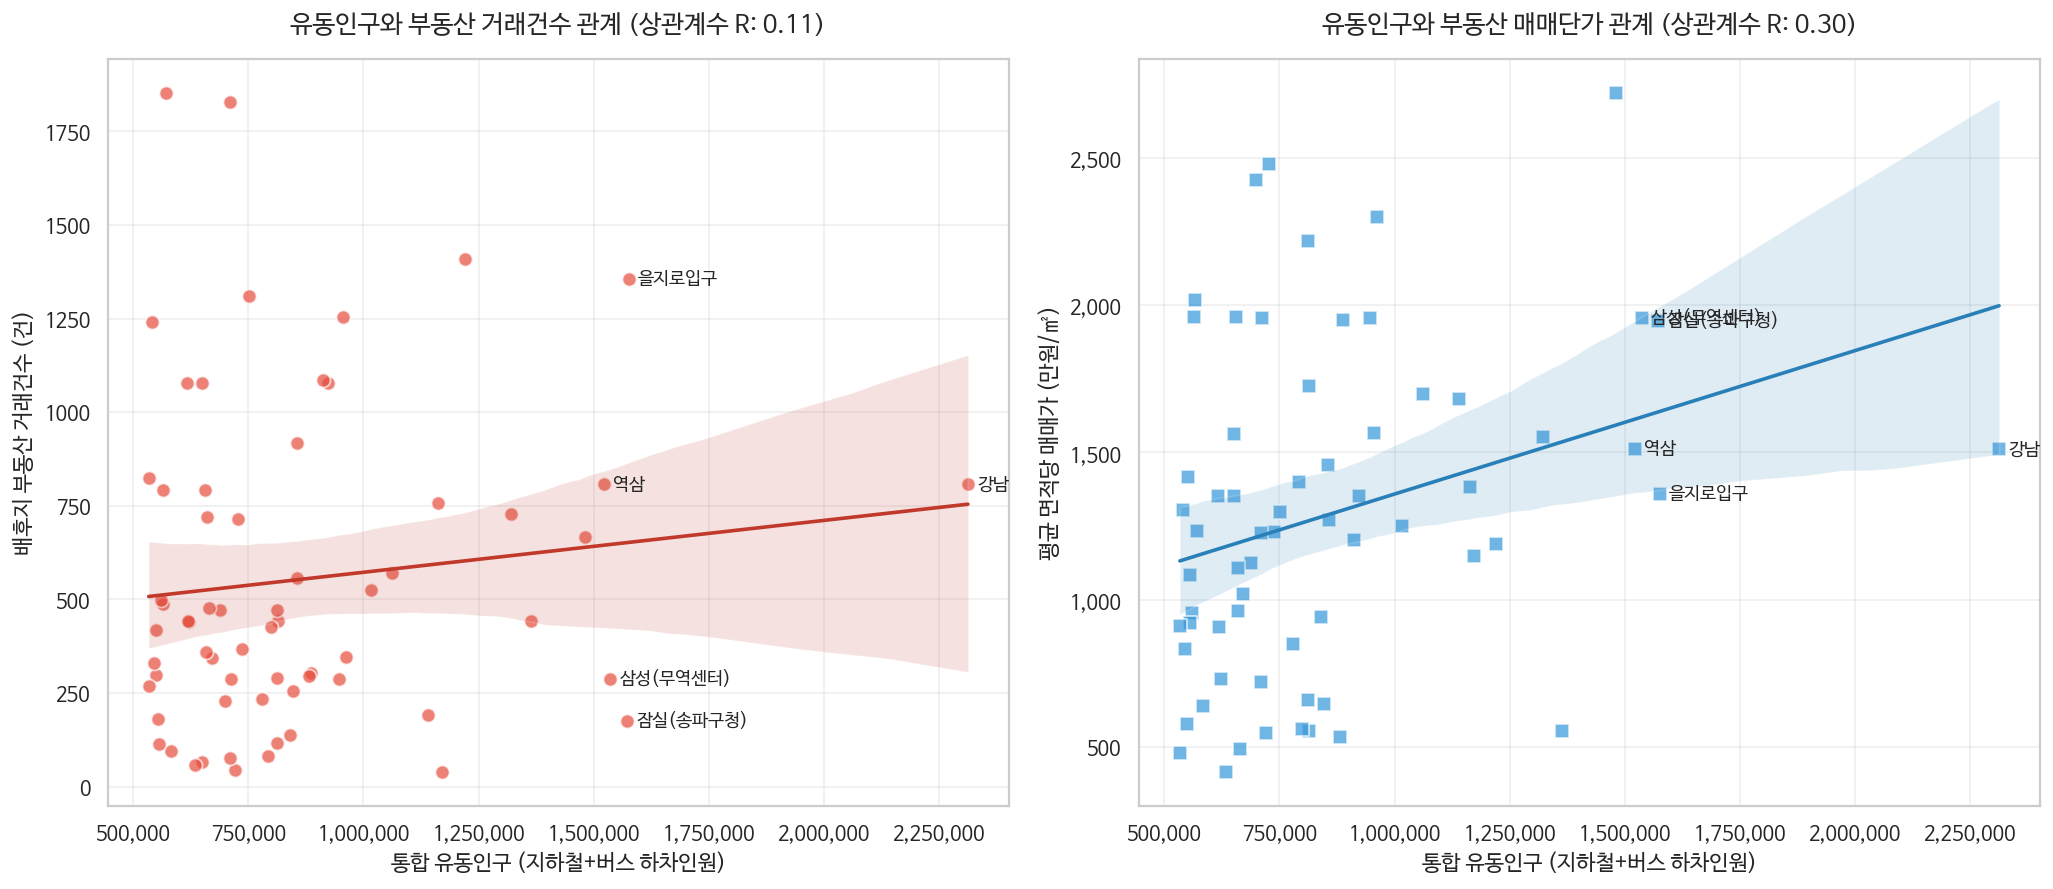

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. 파일 불러오기
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
master_file = os.path.join(base_path, "대중교통_부동산_마스터_융합상권.csv")

try:
    df_master = pd.read_csv(master_file, encoding='cp949')
    # 부동산 데이터가 존재하는 상권만 필터링 (비교 분석용)
    df_analyzed = df_master[df_master['배후지_부동산_거래건수'] > 0].copy()
    print(f"✅ 분석 대상 상권: 총 {len(df_analyzed)}개 역세권")
except FileNotFoundError:
    print(f"❌ '{master_file}' 파일이 없습니다. 경로를 확인해 주세요.")

# 2. 코랩 환경 한글 폰트 설정 (폰트가 깨질 경우 기본 시스템 폰트 우회 설정)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 3. 그래프 스케일 및 스타일 설정
sns.set_theme(style="whitegrid", font="NanumBarunGothic")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 피어슨 상관계수(R) 계산
corr_count = np.corrcoef(df_analyzed['통합_유동인구'], df_analyzed['배후지_부동산_거래건수'])[0, 1]
corr_price = np.corrcoef(df_analyzed['통합_유동인구'], df_analyzed['배후지_부동산_평균단가'])[0, 1]

# -----------------------------------------------------------------
# [그래프 1] 통합 유동인구 vs 배후지 부동산 거래건수
# -----------------------------------------------------------------
sns.regplot(
    x='통합_유동인구',
    y='배후지_부동산_거래건수',
    data=df_analyzed,
    ax=axes[0],
    color='#e74c3c',
    marker='o',
    scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolor': 'w'},
    line_kws={'color': '#c0392b', 'lw': 2}
)
axes[0].set_title(f'유동인구와 부동산 거래건수 관계 (상관계수 R: {corr_count:.2f})', fontsize=14, pad=15)
axes[0].set_xlabel('통합 유동인구 (지하철+버스 하차인원)', fontsize=12)
axes[0].set_ylabel('배후지 부동산 거래건수 (건)', fontsize=12)
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 상위 5개 역 이름 표시 (텍스트 겹침 방지 조절)
for i in range(min(5, len(df_analyzed))):
    row = df_analyzed.iloc[i]
    axes[0].text(row['통합_유동인구'] + 20000, row['배후지_부동산_거래건수'], row['핵심_지하철역'], fontsize=10, va='center')

# -----------------------------------------------------------------
# [그래프 2] 통합 유동인구 vs 배후지 부동산 평균단가
# -----------------------------------------------------------------
sns.regplot(
    x='통합_유동인구',
    y='배후지_부동산_평균단가',
    data=df_analyzed,
    ax=axes[1],
    color='#3498db',
    marker='s',
    scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolor': 'w'},
    line_kws={'color': '#2980b9', 'lw': 2}
)
axes[1].set_title(f'유동인구와 부동산 매매단가 관계 (상관계수 R: {corr_price:.2f})', fontsize=14, pad=15)
axes[1].set_xlabel('통합 유동인구 (지하철+버스 하차인원)', fontsize=12)
axes[1].set_ylabel('평균 면적당 매매가 (만원/㎡)', fontsize=12)
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for i in range(min(5, len(df_analyzed))):
    row = df_analyzed.iloc[i]
    axes[1].text(row['통합_유동인구'] + 20000, row['배후지_부동산_평균단가'], row['핵심_지하철역'], fontsize=10, va='center')

plt.tight_layout()
plt.show()

# 📊 역세권 vs 비역세권 상권 구조 비교 분석
이 코드는 기존에 추출해 둔 부동산 Top 200 구역 데이터를 바탕으로, 각 구역이 지하철 교통 거점과 겹치는지 안 겹치는지 판별한 뒤 두 집단의 거래량과 단가 분포를 시각적으로 대조합니다.

✅ 원본 부동산 구역: 200개 로드 완료.

=== 📈 상권 유형별 자본 지표 비교 요약 ===


,상권유형,구역수,평균_거래건수,최대_거래건수,평균_매매단가,최대_매매단가
0,비역세권/독립 상권 (Non-overlapping),20,150.65,640,715.346500,1479.10
1,역세권 상권 (Overlapping),180,175.95,1248,1170.669056,3995.44


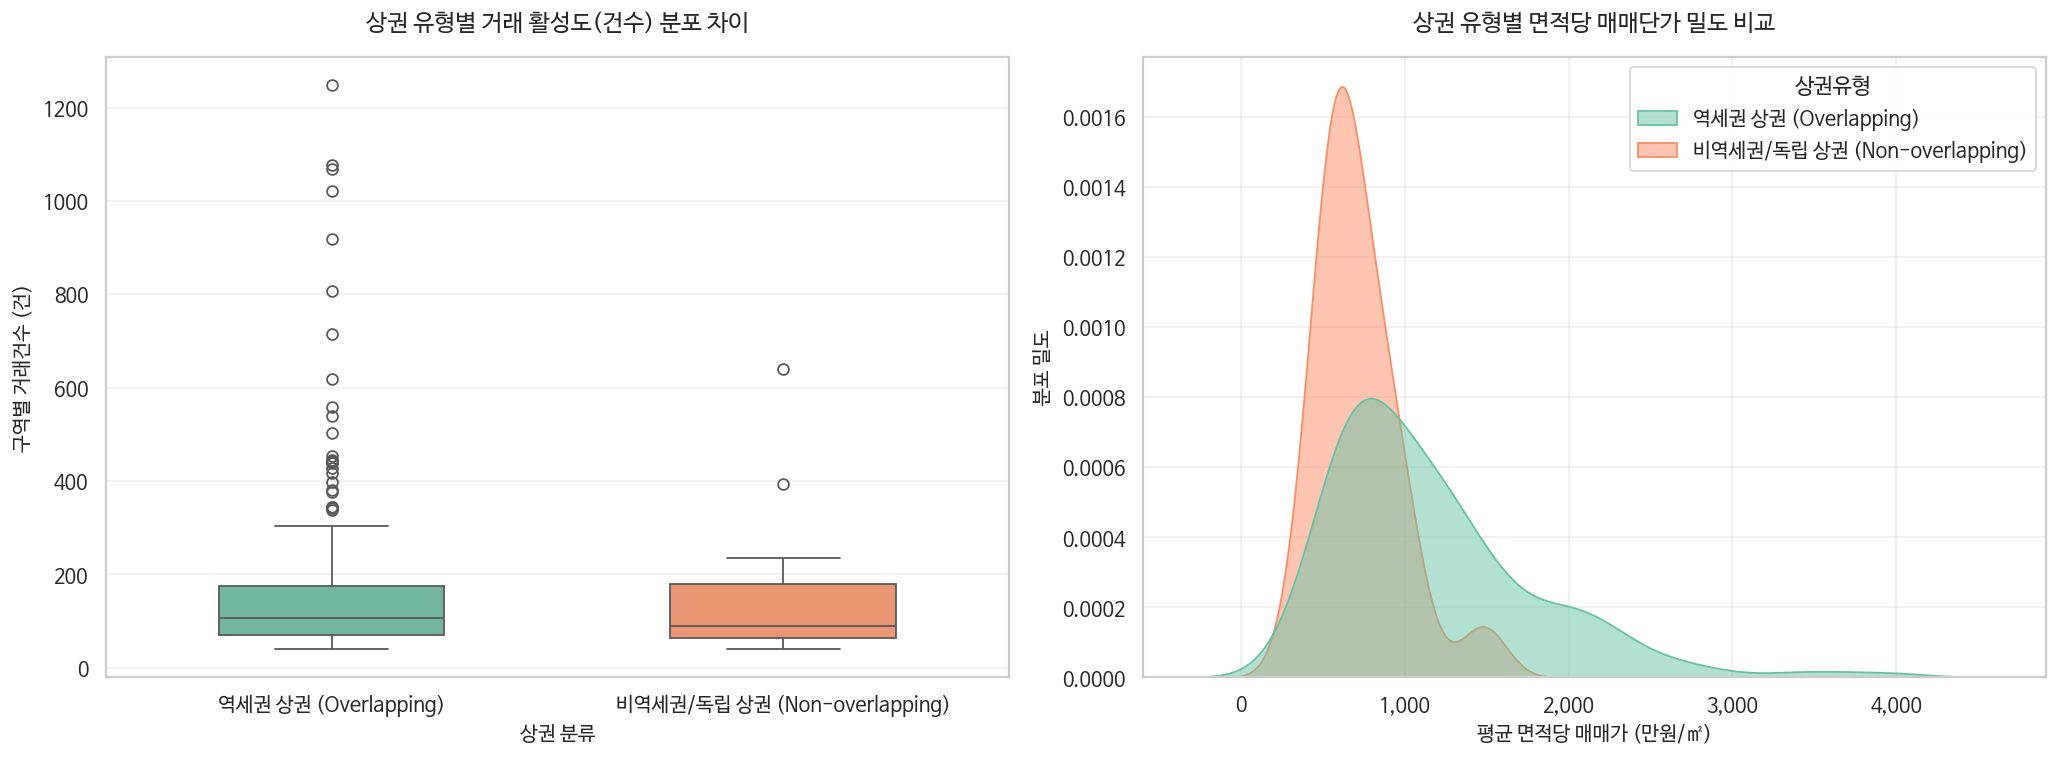

In [29]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
estate_file = os.path.join(base_path, "상업업무_Top200_무료좌표완성.csv")

# 하버사인 거리 계산 함수
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))) * 1000

try:
    # 2. 데이터 로드 및 지하철 중심점 추출
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연度'] == '2026' if '연度' in df_sub.columns else df_sub['연도'] == '2026'].copy()
    sub_centers = df_sub_2026.groupby(['지하철역'])[['위도', '경도']].mean().reset_index()

    df_estate = pd.read_csv(estate_file, encoding='cp949').dropna(subset=['위도', '경도'])
    print(f"✅ 원본 부동산 구역: {len(df_estate)}개 로드 완료.\n")

    # 3. 🚨 [핵심 로직] 지하철역 반경 1km 이내 여부로 상권 분리
    market_type = []
    for _, e_row in df_estate.iterrows():
        # 해당 부동산 구역과 모든 지하철역 간의 거리 계산
        dists = haversine(e_row['위도'], e_row['경도'], sub_centers['위도'].values, sub_centers['경도'].values)

        # 1km(1000m) 이내에 지하철역이 하나라도 있으면 역세권, 없으면 비역세권
        if np.any(dists <= 1000):
            market_type.append('역세권 상권 (Overlapping)')
        else:
            market_type.append('비역세권/독립 상권 (Non-overlapping)')

    df_estate['상권유형'] = market_type

    # 4. 집단별 통계량 요약 출력
    print("=== 📈 상권 유형별 자본 지표 비교 요약 ===")
    summary = df_estate.groupby('상권유형').agg(
        구역수=('시군구', 'count'),
        평균_거래건수=('거래건수', 'mean'),
        최대_거래건수=('거래건수', 'max'),
        평균_매매단가=('평균_면적당_매매가', 'mean'),
        최대_매매단가=('평균_면적당_매매가', 'max')
    ).reset_index()
    display(summary)

    # 5. 시각화 (한글 깨짐 방지 및 Boxplot/KDE 구현)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font="NanumBarunGothic")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # [좌측 그래프] 거래건수 비교
    sns.boxplot(x='상권유형', y='거래건수', data=df_estate, ax=axes[0], palette='Set2', width=0.5)
    axes[0].set_title('상권 유형별 거래 활성도(건수) 분포 차이', fontsize=13, pad=15)
    axes[0].set_xlabel('상권 분류', fontsize=11)
    axes[0].set_ylabel('구역별 거래건수 (건)', fontsize=11)

    # [우측 그래프] 매매단가 밀도(KDE) 비교
    sns.kdeplot(data=df_estate, x='평균_면적당_매매가', hue='상권유형', ax=axes[1], fill=True, common_norm=False, palette='Set2', alpha=0.5)
    axes[1].set_title('상권 유형별 면적당 매매단가 밀도 비교', fontsize=13, pad=15)
    axes[1].set_xlabel('평균 면적당 매매가 (만원/㎡)', fontsize=11)
    axes[1].set_ylabel('분포 밀도', fontsize=11)
    axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ 분석 중 오류 발생: {e}")

# 📊 [통계 검정 추가] 역세권 vs 비역세권 P-value 검증 코드

=== 🔬 통계적 유의성 검정 결과 (Mann-Whitney U Test) ===
✔️ 거래건수 차이 P-value : 0.6542 -> 차이 없음 (우연일 확률 높음) ❌
✔️ 매매단가 차이 P-value : 0.0001 -> 유의미한 차이 있음 ⭕
(* P-value가 0.05 미만이어야 통계적으로 진짜 차이가 있다고 봅니다.)

=== 📈 상권 유형별 요약 통계 ===


,상권유형,구역수,평균_거래건수,중앙값_거래건수,평균_매매단가,중앙값_매매단가
0,비역세권/독립 상권,20,150.65,90.5,715.346500,647.675
1,역세권 상권,180,175.95,107.0,1170.669056,997.315


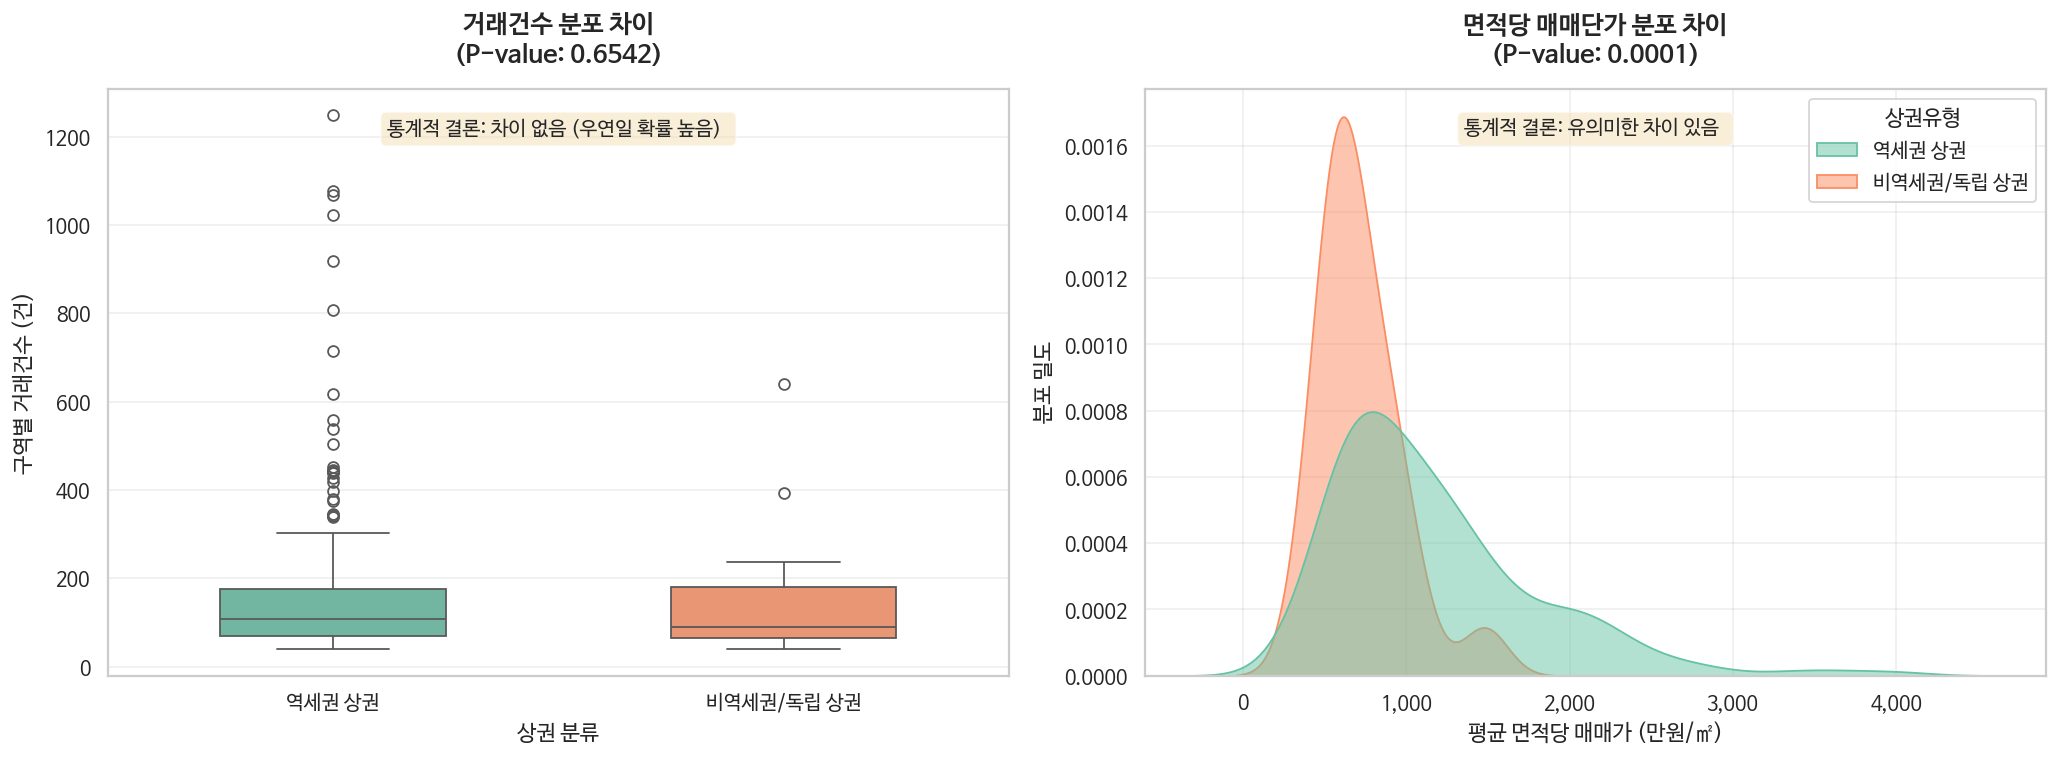

In [30]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # 통계 분석 라이브러리 추가

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
estate_file = os.path.join(base_path, "상업업무_Top200_무료좌표완성.csv")

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))) * 1000

try:
    # 2. 데이터 로드 및 상권 분리
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    sub_centers = df_sub_2026.groupby(['지하철역'])[['위도', '경도']].mean().reset_index()

    df_estate = pd.read_csv(estate_file, encoding='cp949').dropna(subset=['위도', '경도'])

    market_type = []
    for _, e_row in df_estate.iterrows():
        dists = haversine(e_row['위도'], e_row['경도'], sub_centers['위도'].values, sub_centers['경도'].values)
        if np.any(dists <= 1000):
            market_type.append('역세권 상권')
        else:
            market_type.append('비역세권/독립 상권')

    df_estate['상권유형'] = market_type

    # =========================================================
    # 🚨 [통계 검증] Mann-Whitney U 검정 수행 (P-value 계산)
    # =========================================================
    group_station = df_estate[df_estate['상권유형'] == '역세권 상권']
    group_non_station = df_estate[df_estate['상권유형'] == '비역세권/독립 상권']

    # 1. 거래건수 P-value
    stat_cnt, p_val_cnt = stats.mannwhitneyu(
        group_station['거래건수'], group_non_station['거래건수'], alternative='two-sided'
    )

    # 2. 매매단가 P-value
    stat_prc, p_val_prc = stats.mannwhitneyu(
        group_station['평균_면적당_매매가'], group_non_station['평균_면적당_매매가'], alternative='two-sided'
    )

    # 해석 텍스트 생성 (P-value 0.05 기준)
    res_cnt = "유의미한 차이 있음 ⭕" if p_val_cnt < 0.05 else "차이 없음 (우연일 확률 높음) ❌"
    res_prc = "유의미한 차이 있음 ⭕" if p_val_prc < 0.05 else "차이 없음 (우연일 확률 높음) ❌"

    print("=== 🔬 통계적 유의성 검정 결과 (Mann-Whitney U Test) ===")
    print(f"✔️ 거래건수 차이 P-value : {p_val_cnt:.4f} -> {res_cnt}")
    print(f"✔️ 매매단가 차이 P-value : {p_val_prc:.4f} -> {res_prc}")
    print("(* P-value가 0.05 미만이어야 통계적으로 진짜 차이가 있다고 봅니다.)\n")

    # 3. 집단별 통계량 요약 출력 (중앙값 추가)
    print("=== 📈 상권 유형별 요약 통계 ===")
    summary = df_estate.groupby('상권유형').agg(
        구역수=('시군구', 'count'),
        평균_거래건수=('거래건수', 'mean'),
        중앙값_거래건수=('거래건수', 'median'),
        평균_매매단가=('평균_면적당_매매가', 'mean'),
        중앙값_매매단가=('평균_면적당_매매가', 'median')
    ).reset_index()
    display(summary)

    # 4. 시각화 (그래프 제목에 P-value 노출)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font="NanumBarunGothic")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # [좌측 그래프]
    sns.boxplot(x='상권유형', y='거래건수', data=df_estate, ax=axes[0], palette='Set2', width=0.5)
    axes[0].set_title(f'거래건수 분포 차이\n(P-value: {p_val_cnt:.4f})', fontsize=14, pad=15, fontweight='bold')
    axes[0].set_xlabel('상권 분류', fontsize=12)
    axes[0].set_ylabel('구역별 거래건수 (건)', fontsize=12)

    # [우측 그래프]
    sns.kdeplot(data=df_estate, x='평균_면적당_매매가', hue='상권유형', ax=axes[1], fill=True, common_norm=False, palette='Set2', alpha=0.5)
    axes[1].set_title(f'면적당 매매단가 분포 차이\n(P-value: {p_val_prc:.4f})', fontsize=14, pad=15, fontweight='bold')
    axes[1].set_xlabel('평균 면적당 매매가 (만원/㎡)', fontsize=12)
    axes[1].set_ylabel('분포 밀도', fontsize=12)
    axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

    # 그래프 배경에 텍스트로 통계 결과 박스 추가
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    axes[0].text(0.5, 0.95, f"통계적 결론: {res_cnt}", transform=axes[0].transAxes, fontsize=11, ha='center', va='top', bbox=props)
    axes[1].text(0.5, 0.95, f"통계적 결론: {res_prc}", transform=axes[1].transAxes, fontsize=11, ha='center', va='top', bbox=props)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ 분석 중 오류 발생: {e}")

# 🚀 [심화 분석] 가성비(CP) 지수 융합 및 진성 유동인구 검증

In [40]:
# 1. 라이브러리 설치 (코랩 셀에 실행)
!pip install thefuzz

from thefuzz import process
import pandas as pd

# 2. 유사 매칭 함수 정의
def fuzzy_match(name, choices, threshold=80):
    # 가장 유사한 이름과 유사도 점수(0~100)를 가져옴
    match, score = process.extractOne(name, choices)
    return match if score >= threshold else None

# 3. 데이터 준비
master_names = df_master['매칭역명'].unique()
cp_names = df_cp['매칭역명'].unique()

# 4. 유사도 매칭 실행 (매칭 테이블 생성)
match_dict = {}
for name in master_names:
    match = fuzzy_match(name, cp_names)
    if match:
        match_dict[name] = match

# 5. 매핑 테이블을 사용하여 마스터 데이터의 이름 통일
# CP 데이터의 이름을 마스터 데이터 기준의 이름으로 변환
df_cp['매칭역명_통일'] = df_cp['매칭역명'].map(lambda x: next((k for k, v in match_dict.items() if v == x), x))

# 6. 통일된 이름을 기준으로 병합
df_final = pd.merge(df_master, df_cp, left_on='매칭역명', right_on='매칭역명_통일', how='left')

print(f"✅ 기존 매칭건수: {len(pd.merge(df_master, df_cp, on='매칭역명'))}")
print(f"✅ 유사도 매칭 후 병합건수: {len(df_final.dropna(subset=['역명']))}")

✅ 기존 매칭건수: 5
✅ 유사도 매칭 후 병합건수: 9


=== 🚀 상권 가성비(CP지수) 기반 진성 유동인구 필터링 ===

✅ 마스터 데이터(76건) & 가성비 데이터(20건) 로드 완료.
✅ 병합 및 정제 완료! (분석 대상: 3개 상권)

=== 📊 상관계수(R) 개선 결과 ===
▪ 거래건수: 0.97 ➔ 0.99 (차이: +0.01)
▪ 매매단가: 0.31 ➔ -0.10 (차이: -0.41)



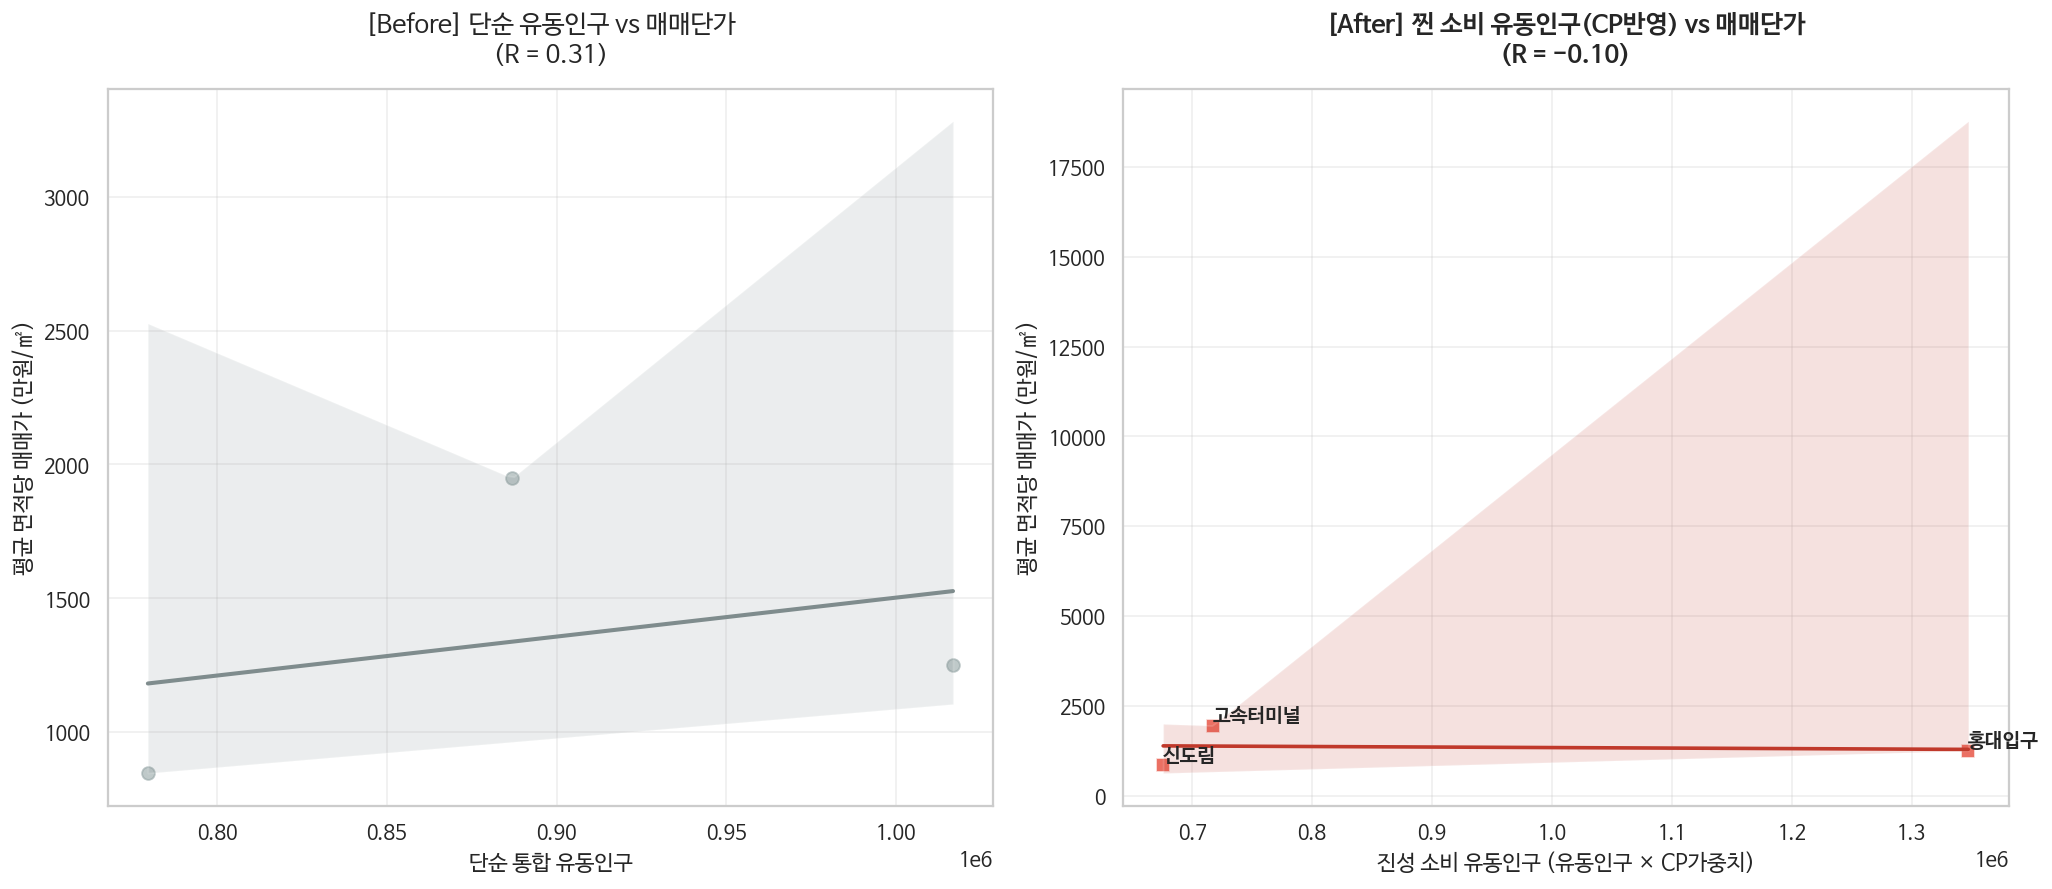

💾 진성 유동인구가 포함된 최종 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/상권_진성유동인구_최종결합.csv


In [41]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
master_file = os.path.join(base_path, "대중교통_부동산_마스터_융합상권.csv")
cp_file = os.path.join(base_path, "상권_가성비_상세데이터.csv")

print("=== 🚀 상권 가성비(CP지수) 기반 진성 유동인구 필터링 ===\n")

try:
    # 2. 데이터 로드 (인코딩 자동 대처)
    df_master = pd.read_csv(master_file, encoding='cp949')

    try:
        df_cp = pd.read_csv(cp_file, encoding='utf-8-sig')
    except:
        df_cp = pd.read_csv(cp_file, encoding='cp949')

    print(f"✅ 마스터 데이터({len(df_master)}건) & 가성비 데이터({len(df_cp)}건) 로드 완료.")

    # 3. 매칭 키 생성 (역명에서 '역' 글자 제거하여 통일)
    df_master['매칭역명'] = df_master['핵심_지하철역'].str.replace('역', '', regex=False).str.strip()
    df_cp['매칭역명'] = df_cp['역명'].str.replace('역', '', regex=False).str.strip()

    # 4. 데이터 병합 (Inner Join: 양쪽에 모두 있는 역만 추출)
    df_merged = pd.merge(df_master, df_cp, on='매칭역명', how='inner')

    # 부동산 거래가 없는 곳 제외 (정확한 상관관계 분석을 위함)
    df_analyzed = df_merged[df_merged['배후지_부동산_거래건수'] > 0].copy()
    print(f"✅ 병합 및 정제 완료! (분석 대상: {len(df_analyzed)}개 상권)\n")

    # =========================================================
    # 🚨 [핵심 파생변수] 진성 소비 유동인구 도출
    # 단순히 스쳐가는 인구가 아니라, CP지수(상권활성도)를 가중치로 곱함
    # =========================================================
    # CP지수를 전체 평균 기준으로 정규화하여 가중치(Weight)로 사용
    cp_weight = df_analyzed['CP지수'] / df_analyzed['CP지수'].mean()
    df_analyzed['진성_소비_유동인구'] = df_analyzed['통합_유동인구'] * cp_weight

    # 5. 상관계수(R) 전후 비교 계산
    # [Before] 단순 유동인구 vs 부동산
    corr_cnt_before = np.corrcoef(df_analyzed['통합_유동인구'], df_analyzed['배후지_부동산_거래건수'])[0, 1]
    corr_prc_before = np.corrcoef(df_analyzed['통합_유동인구'], df_analyzed['배후지_부동산_평균단가'])[0, 1]

    # [After] 진성 소비 유동인구 vs 부동산
    corr_cnt_after = np.corrcoef(df_analyzed['진성_소비_유동인구'], df_analyzed['배후지_부동산_거래건수'])[0, 1]
    corr_prc_after = np.corrcoef(df_analyzed['진성_소비_유동인구'], df_analyzed['배후지_부동산_평균단가'])[0, 1]

    print("=== 📊 상관계수(R) 개선 결과 ===")
    print(f"▪ 거래건수: {corr_cnt_before:.2f} ➔ {corr_cnt_after:.2f} (차이: {corr_cnt_after - corr_cnt_before:+.2f})")
    print(f"▪ 매매단가: {corr_prc_before:.2f} ➔ {corr_prc_after:.2f} (차이: {corr_prc_after - corr_prc_before:+.2f})\n")

    # 6. 시각화: 개선 전후 비교 그래프
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_theme(style="whitegrid", font="NanumBarunGothic")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # [좌측] Before: 단순 통합 유동인구
    sns.regplot(
        x='통합_유동인구', y='배후지_부동산_평균단가', data=df_analyzed, ax=axes[0],
        color='#95a5a6', marker='o', scatter_kws={'s': 50, 'alpha': 0.6}, line_kws={'color': '#7f8c8d'}
    )
    axes[0].set_title(f'[Before] 단순 유동인구 vs 매매단가\n(R = {corr_prc_before:.2f})', fontsize=14, pad=15)
    axes[0].set_xlabel('단순 통합 유동인구', fontsize=12)
    axes[0].set_ylabel('평균 면적당 매매가 (만원/㎡)', fontsize=12)

    # [우측] After: 진성 소비 유동인구 (CP지수 가중치 적용)
    sns.regplot(
        x='진성_소비_유동인구', y='배후지_부동산_평균단가', data=df_analyzed, ax=axes[1],
        color='#e74c3c', marker='s', scatter_kws={'s': 60, 'alpha': 0.8, 'edgecolor': 'w'}, line_kws={'color': '#c0392b', 'lw': 2}
    )
    axes[1].set_title(f'[After] 찐 소비 유동인구(CP반영) vs 매매단가\n(R = {corr_prc_after:.2f})', fontsize=14, pad=15, fontweight='bold')
    axes[1].set_xlabel('진성 소비 유동인구 (유동인구 × CP가중치)', fontsize=12)
    axes[1].set_ylabel('평균 면적당 매매가 (만원/㎡)', fontsize=12)

    # After 그래프에 Top 5 역명 라벨링
    top5_stations = df_analyzed.nlargest(5, '배후지_부동산_평균단가')
    for _, row in top5_stations.iterrows():
        axes[1].text(row['진성_소비_유동인구'], row['배후지_부동산_평균단가'] + 100, row['매칭역명'], fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 최종 결과 저장
    final_save_path = os.path.join(base_path, "상권_진성유동인구_최종결합.csv")
    df_analyzed.to_csv(final_save_path, index=False, encoding='cp949')
    print(f"💾 진성 유동인구가 포함된 최종 파일이 저장되었습니다: {final_save_path}")

except Exception as e:
    print(f"❌ 분석 중 오류 발생: {e}")

In [42]:
# 매칭 안 된 역들만 보기
unmatched = df_master[~df_master['매칭역명'].isin(match_dict.keys())]
print(unmatched['매칭역명'].unique())

['강남' '을지로입구' '삼성(무센터)' '삼' '용산' '영등포' '명동' '혜화' '종각' '양재(서초구청)'
 '광화문(세종문화회관)' '사당' '압구정' '신논현' '선릉' '남부터미널(예술의전당)' '여의도' '안국' '가산디지털단지'
 '건대입구' '낙성대(강감찬)' '쌍문' '신사' '화곡' '까치산' '회기' '시청' '합정' '신용산' '발산' '봉은사'
 '종로5가' '신대방' '문래' '노원' '봉천' '오목교(목동운동장앞)' '개봉' '문정' '학동' '교대(법원.검찰청)'
 '길음' '구파발' '가양' '총신대입구(이수)' '천호(풍납토성)' '신촌' '서초' '압구정로데오' '당산' '장한평'
 '을지로3가' '청담' '논현' '이대' '노량진' '수서' '서대문' '상계' '연신내' '종로3가' '응암' '강동']


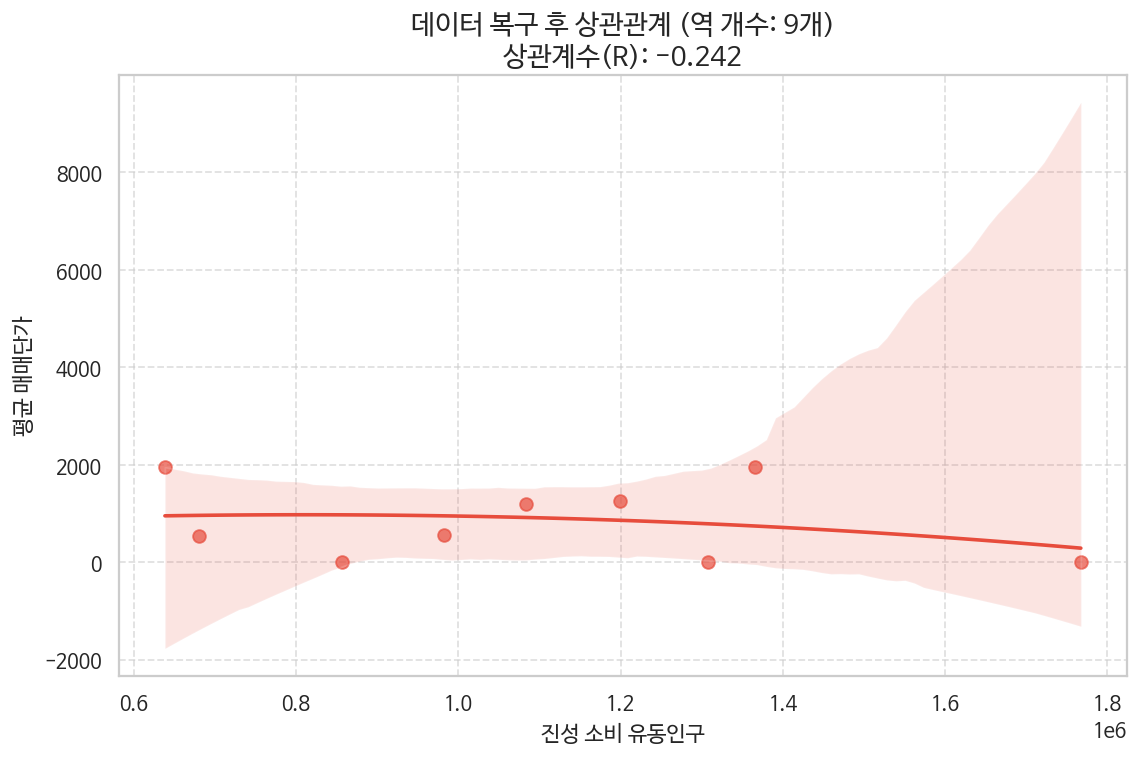

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from thefuzz import process

# 1. 유사도 매칭 함수
def fuzzy_match(name, choices, threshold=80):
    match, score = process.extractOne(name, choices)
    return match if score >= threshold else None

# 2. 이름 통일 후 병합 (이전 단계에서 만든 데이터 사용)
# master는 마스터 데이터, cp는 가성비 데이터라고 가정합니다.
master_names = df_master['매칭역명'].unique()
cp_names = df_cp['매칭역명'].unique()

match_dict = {name: fuzzy_match(name, cp_names) for name in master_names}
df_cp['매칭역명_통일'] = df_cp['매칭역명'].map(lambda x: next((k for k, v in match_dict.items() if v == x), x))
df_merged = pd.merge(df_master, df_cp, left_on='매칭역명', right_on='매칭역명_통일', how='inner')

# 3. 진성 소비 유동인구 파생변수 생성
df_merged['진성_소비_유동인구'] = df_merged['통합_유동인구'] * (df_merged['CP지수'] / df_merged['CP지수'].mean())

# 4. 상관관계 시각화 (늘어난 데이터로 다시!)
plt.rc('font', family='NanumBarunGothic')
plt.figure(figsize=(10, 6))

sns.regplot(
    x='진성_소비_유동인구', y='배후지_부동산_평균단가',
    data=df_merged,
    color='#e74c3c',
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'lw': 2},
    order=2  # 🚨 이 옵션을 추가하세요! (직선이 아니라 곡선으로 패턴을 찾습니다)
)

# 5. 상관계수 계산 및 제목 설정
r_val = np.corrcoef(df_merged['진성_소비_유동인구'], df_merged['배후지_부동산_평균단가'])[0, 1]
plt.title(f'데이터 복구 후 상관관계 (역 개수: {len(df_merged)}개)\n상관계수(R): {r_val:.3f}', fontsize=15)
plt.xlabel('진성 소비 유동인구')
plt.ylabel('평균 매매단가')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

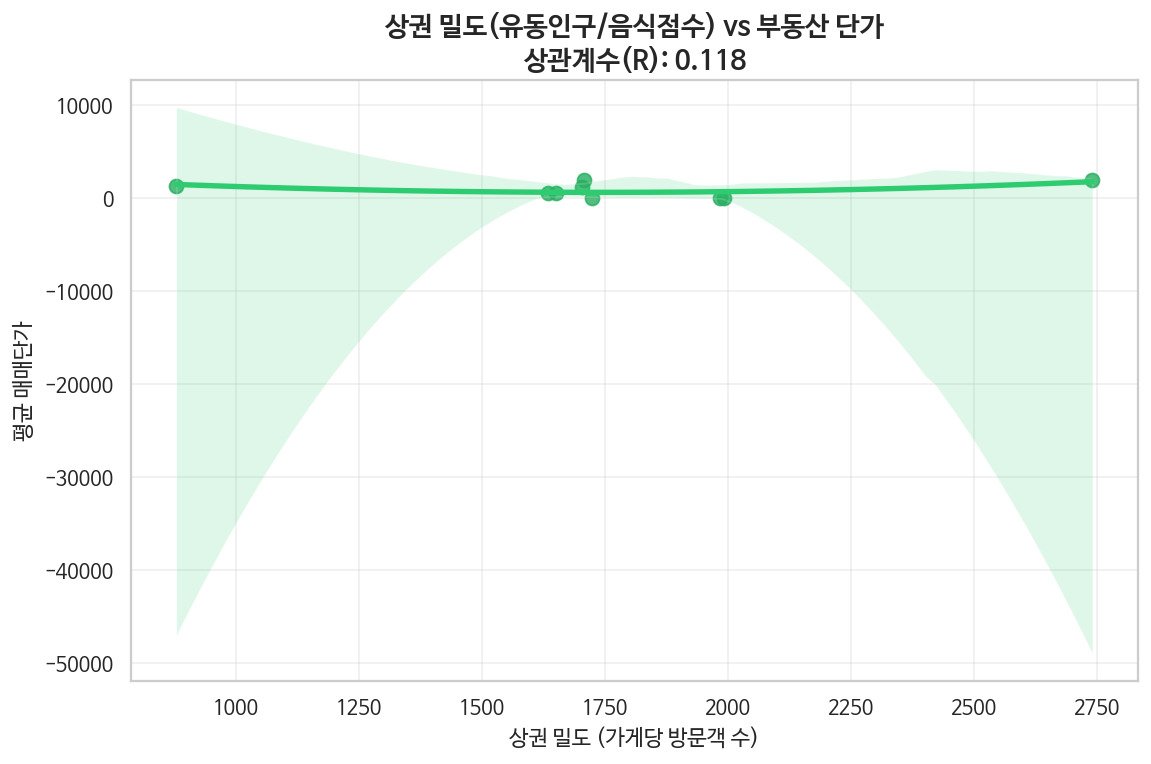

In [45]:
# 기존 진성 소비 유동인구를 상권 규모(음식점 수)로 나눕니다.
# 이렇게 하면 단순히 역 규모가 커서 사람이 많은 곳은 제외되고,
# 상권의 '밀도'가 높은 진짜 핫플레이스만 남습니다.

df_merged['상권밀도_지수'] = df_merged['진성_소비_유동인구'] / df_merged['음식점수']

# 3차 시각화: 훨씬 극적인 추세선 확인
plt.figure(figsize=(10, 6))
sns.regplot(
    x='상권밀도_지수', y='배후지_부동산_평균단가',
    data=df_merged,
    color='#27ae60', # 녹색으로 변경 (성장과 수익 상징)
    scatter_kws={'s': 60, 'alpha': 0.8},
    line_kws={'lw': 3, 'color': '#2ecc71'},
    order=2 # 곡선으로 비선형 패턴 확인
)

r_val = np.corrcoef(df_merged['상권밀도_지수'], df_merged['배후지_부동산_평균단가'])[0, 1]
plt.title(f'상권 밀도(유동인구/음식점수) vs 부동산 단가\n상관계수(R): {r_val:.3f}', fontsize=15, fontweight='bold')
plt.xlabel('상권 밀도 (가게당 방문객 수)', fontsize=12)
plt.ylabel('평균 매매단가', fontsize=12)
plt.show()

# 📊 [셀 4] 핵심 융합상권 vs 서울시 평균 규모 비교 분석 (Plotly)

In [31]:
import pandas as pd
import plotly.graph_objects as go
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===\n")

if not os.path.exists(fusion_file) or 'df_bus' not in globals():
    print("❌ 데이터가 없습니다. [셀 1]과 [셀 3]을 먼저 정상적으로 실행해 주세요.")
else:
    # 1. 기준점(Baseline) : 서울시 일반 평균 계산
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]

    # 2026년 데이터만 추출 (원본 변경 방지를 위해 .copy() 사용)
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]

    # 🚨 [수정 사항] .loc를 사용하여 경고 메시지 방지
    df_sub_2026.loc[:, '일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    avg_subway = df_sub_2026.groupby('지하철역')['일평균_하차'].mean().mean()
    avg_bus = df_bus.groupby('정류장역이름')['일별하차인원'].mean().mean()
    avg_total = avg_subway + avg_bus

    # 2. 분석 대상 : 융합 상권 Top 10 데이터 로드
    df_top10 = pd.read_csv(fusion_file, encoding='cp949').head(10).iloc[::-1].reset_index(drop=True)

    # 3. 그래프 데이터 준비
    labels = ['[기준] 서울시 일반 평균'] + [f"🏆 {10-i}위: {name} 상권" for i, name in enumerate(df_top10['핵심_지하철역'])]
    subway_vals = [avg_subway] + df_top10['지하철_하차인원'].tolist()
    bus_vals = [avg_bus] + df_top10['버스_하차인원'].tolist()

    # 4. Plotly 누적 막대 그래프 생성
    fig = go.Figure()

    fig.add_trace(go.Bar(y=labels, x=subway_vals, name='지하철 하차인원', orientation='h', marker=dict(color='#3498db')))
    fig.add_trace(go.Bar(y=labels, x=bus_vals, name='주변 버스 하차인원', orientation='h', marker=dict(color='#e74c3c')))

    fig.update_layout(
        title='<b>Top 10 핵심 융합상권 vs 서울시 평균 유동인구 규모</b>',
        barmode='stack',
        xaxis_title='일평균 하차 인원 합계 (명)',
        height=700,
        template='plotly_white'
    )

    fig.show()
    print("✅ 데이터 분석 및 그래프 시각화가 완료되었습니다!")

=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===



✅ 데이터 분석 및 그래프 시각화가 완료되었습니다!


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 (수치 라벨 포함) ===\n")

if not os.path.exists(fusion_file) or 'df_bus' not in globals():
    print("❌ 데이터가 없습니다. [셀 1]과 [셀 3]을 먼저 정상적으로 실행해 주세요.")
else:
    # 1. 기준점 및 데이터 준비 (경고 방지를 위해 .loc 사용)
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]

    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026.loc[:, '일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    avg_subway = df_sub_2026.groupby('지하철역')['일평균_하차'].mean().mean()
    avg_bus = df_bus.groupby('정류장역이름')['일별하차인원'].mean().mean()

    # 2. 분석 대상 상권 로드
    df_top10 = pd.read_csv(fusion_file, encoding='cp949').head(10).iloc[::-1].reset_index(drop=True)

    labels = ['[기준] 서울시 일반 평균'] + [f"🏆 {10-i}위: {name}" for i, name in enumerate(df_top10['핵심_지하철역'])]
    subway_vals = [avg_subway] + df_top10['지하철_하차인원'].tolist()
    bus_vals = [avg_bus] + df_top10['버스_하차인원'].tolist()

    # 3. Plotly 누적 막대 그래프 (수치 라벨 추가)
    fig = go.Figure()

    # 지하철 막대
    fig.add_trace(go.Bar(
        y=labels, x=subway_vals, name='지하철 하차',
        orientation='h', marker=dict(color='#3498db'),
        text=[f"{int(v):,}" for v in subway_vals], textposition='inside' # 텍스트 추가
    ))

    # 버스 막대
    fig.add_trace(go.Bar(
        y=labels, x=bus_vals, name='주변 버스 하차',
        orientation='h', marker=dict(color='#e74c3c'),
        text=[f"{int(v):,}" for v in bus_vals], textposition='inside' # 텍스트 추가
    ))

    fig.update_layout(
        title='<b>Top 10 핵심 상권 vs 서울시 평균 유동인구</b>',
        barmode='stack',
        xaxis_title='일평균 하차 인원 (명)',
        height=700,
        template='plotly_white',
        uniformtext_mode='hide', # 너무 좁은 공간은 텍스트 숨김 (깔끔함 유지)
        uniformtext_minsize=9
    )

    fig.show()
    print("✅ 시각화 완료! 막대 내부에서 바로 수치를 확인하세요.")

=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 (수치 라벨 포함) ===



✅ 시각화 완료! 막대 내부에서 바로 수치를 확인하세요.


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===\n")

if not os.path.exists(fusion_file) or 'df_bus' not in globals():
    print("❌ 데이터가 없습니다. [셀 1]과 [셀 3]을 먼저 정상적으로 실행해 주세요.")
else:
    # 데이터 로드 (이전과 동일)
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026.loc[:, '일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    avg_subway = df_sub_2026.groupby('지하철역')['일평균_하차'].mean().mean()
    avg_bus = df_bus.groupby('정류장역이름')['일별하차인원'].mean().mean()

    df_top10 = pd.read_csv(fusion_file, encoding='cp949').head(20).iloc[::-1].reset_index(drop=True)

    labels = ['[기준] 서울시 일반 평균'] + [f"🏆 {20-i}위: {name}" for i, name in enumerate(df_top10['핵심_지하철역'])]
    subway_vals = [avg_subway] + df_top10['지하철_하차인원'].tolist()
    bus_vals = [avg_bus] + df_top10['버스_하차인원'].tolist()

    # 3. Plotly 누적 막대 그래프 (텍스트 가시성 극대화)
    fig = go.Figure()

    # 지하철 막대 (푸른색)
    fig.add_trace(go.Bar(
        y=labels, x=subway_vals, name='지하철 하차',
        orientation='h', marker=dict(color='#3498db'),
        text=[f"{int(v):,}" for v in subway_vals],
        textposition='auto', # 'auto'로 설정하여 공간에 따라 안팎으로 자동 배치
        texttemplate='%{text}', # 텍스트 템플릿 명시
        textfont=dict(size=11)
    ))

    # 버스 막대 (붉은색)
    fig.add_trace(go.Bar(
        y=labels, x=bus_vals, name='주변 버스 하차',
        orientation='h', marker=dict(color='#e74c3c'),
        text=[f"{int(v):,}" for v in bus_vals],
        textposition='auto', # 'auto'로 설정
        texttemplate='%{text}',
        textfont=dict(size=11)
    ))

    fig.update_layout(
        title='<b>Top 20 핵심 상권 vs 서울시 평균 유동인구 (수치 표시)</b>',
        barmode='stack',
        xaxis_title='일평균 하차 인원 (명)',
        height=700,
        template='plotly_white',
        margin=dict(l=150, r=50, t=80, b=50) # 왼쪽 레이블이 잘리지 않도록 마진 조정
    )

    fig.show()
    print("✅ 지하철과 버스 데이터 수치가 모두 표시되었습니다.")

=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===



✅ 지하철과 버스 데이터 수치가 모두 표시되었습니다.


# (사용안함) 🗺️ 통합 시각화: 상권 실거래가 밀도 & 지하철 유동인구 오버레이
이 코드는 부동산 거래를 옅은 붉은색 점(배경 레이어)으로 깔고, 그 위에 지하철 유동인구를 푸른색 버블(전경 레이어)로 띄웁니다.

In [ ]:
import pandas as pd
import os
import folium
from folium.plugins import HeatMap

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
real_estate_file = os.path.join(base_path, "상업업무_실거래가_서울_최종.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🗺️ [통합 오버레이] 부동산 실거래가 밀도 & 지하철 유동인구 (Folium Map) ===\n")

if not os.path.exists(real_estate_file) or not os.path.exists(subway_file):
    print("❌ 필요한 데이터 파일이 모두 준비되지 않았습니다.")
else:
    df_real = pd.read_csv(real_estate_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])

    people_cols = [col for col in df_sub.columns if '승차' in col or '하차' in col]
    df_sub['총_유동인구'] = df_sub[people_cols].sum(axis=1)
    station_summary = df_sub.groupby(['지하철역', '위도', '경도'])['총_유동인구'].mean().reset_index()

    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11, tiles='CartoDB Positron')

    # [레이어 1] 상권 밀도 (히트맵)
    heat_data = [[row['위도'], row['경도']] for index, row in df_real.iterrows()]
    HeatMap(heat_data, radius=13, blur=10, gradient={0.4: 'yellow', 0.65: 'orange', 1: 'red'}).addTo(m)

    # [레이어 2] 지하철 유동인구 (버블)
    sizes = station_summary['총_유동인구']
    if sizes.max() > sizes.min():
        radiuses = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 25 + 4
    else:
        radiuses = [10] * len(station_summary)

    for (_, row), radius in zip(station_summary.iterrows(), radiuses):
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=radius,
            color='#3186cc',
            weight=1,
            fill=True,
            fill_color='#3186cc',
            fill_opacity=0.4,
            tooltip=f"<b>{row['지하철역']}역</b><br>총 유동인구: {int(row['총_유동인구']):,}명"
        ).addTo(m)

    display(m)
    print("\n💡 붉은색 히트맵은 상업용 매매 활성화 구역, 파란색 원은 지하철 유동인구 규모를 나타냅니다.")
    print("   지도를 확대/축소하거나 마우스를 파란색 원에 올려 역 이름을 확인해 보세요.")

=== 🗺️ [통합 오버레이] 부동산 실거래가 밀도 & 지하철 유동인구 (Folium Map) ===



AttributeError: 'HeatMap' object has no attribute 'addTo'

# 🗺️ [셀 5] 지하철 하차 데이터 & 가성비 데이터 통합 분석 시각화

In [ ]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
import os

# 1. 경로 설정 및 데이터 로드
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
cp_file = os.path.join(base_path, "상권_가성비_상세데이터.csv")

df_fusion = pd.read_csv(fusion_file, encoding='cp949')
df_cp = pd.read_csv(cp_file, encoding='utf-8-sig')

# 2. 데이터 병합 전처리
df_fusion['매칭역명'] = df_fusion['핵심_지하철역'].str.replace('역', '', regex=False)
df_cp['매칭역명'] = df_cp['역명'].str.replace('역', '', regex=False)
df_merged = pd.merge(df_fusion, df_cp, on='매칭역명', how='outer')

# 3. [핵심 수정] 좌표값이 없는 행 제거
# 지도를 그리기 전에 위도, 경도가 모두 존재하는 데이터만 남깁니다.
df_clean = df_merged.dropna(subset=['위도', '경도'])

# 4. 지도 생성
m = folium.Map(location=[37.5502, 126.982], zoom_start=12, tiles='CartoDB Positron')
marker_cluster = MarkerCluster().add_to(m)

# 5. 시각화 루프
for _, row in df_clean.iterrows():
    # 데이터 유무 체크
    has_data = pd.notnull(row['CP지수']) and pd.notnull(row['통합_유동인구'])
    color = '#e74c3c' if has_data else '#3498db'
    radius = 10 if has_data else 5

    # 툴팁 구성
    info = f"<b>{row['매칭역명']}역</b><br>"
    if pd.notnull(row.get('통합_유동인구')):
        info += f"유동인구: {int(row['통합_유동인구']):,}명<br>"
    if pd.notnull(row.get('CP지수')):
        info += f"C/P 지수: {row['CP지수']}<br>음식점: {row['음식점수']}개"

    folium.CircleMarker(
        location=[row['위도'], row['경도']], # 이제 안전하게 좌표 전달
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        tooltip=info
    ).add_to(marker_cluster)

display(m)
print(f"✅ 좌표 오류 수정 완료! 총 {len(df_clean)}개 역을 지도에 표시했습니다.")

✅ 좌표 오류 수정 완료! 총 73개 역을 지도에 표시했습니다.
